# CineMatch: Movie Recommendation with Machine Learning
### A Project by the DMW Team

Organized and prepared by the DMW Team for the **Data Mining and Warehousing** course.

---

This notebook builds a movie recommendation system on real data scraped from Letterboxd. It follows the same structured workflow used in the ML course references: clean data first, tune hyperparameters second, train and evaluate models third.

**Data source:** `user_ratings_enriched2.csv` — placed directly inside the `geoff run/` folder.

```
geoff run/
  user_ratings_enriched2.csv
ML/
  cinematch_ml_clean.ipynb   <- YOU ARE HERE
```

| Column | Description |
|:---|:---|
| `username` | Letterboxd username |
| `film_slug` | URL-safe film identifier (e.g. `parasite-2019`) |
| `rating` | Star rating given by the user (0.5 to 5.0) |
| `tmdb_id` | The Movie Database numeric ID |
| `proper_title` | Human-readable film title |
| `genre_1` to `genre_5` | Up to five genres per film |

---

## Table of Contents

1. [Install and Import](#1)
2. [Load and Explore the Data](#2)
3. [Data Cleaning and Pre-processing](#3)
4. [Feature Engineering](#4)
5. [User-Item Matrix](#5)
6. [Hyperparameter Tuning](#6) — find the optimal settings for each model BEFORE training
7. [Model 1: Random Forest](#7)
8. [Model 2: k-Nearest Neighbors](#8)
9. [Model 3: Gradient Boosting / XGBoost](#9)
10. [Model 4: Logistic Regression](#10)
11. [Model Comparison](#11)
12. [Train / Test Split Verification](#12)
13. [Learning Curves and Overfitting Diagnosis](#13)
14. [Cross-Validation](#14)
15. [Bias and Fairness Audit](#15)
16. [Full Recommendation Pipeline](#16)


---
<a id='1'></a>
## Section 1 — Install and Import

### What are we doing here?

Before any code can run we install the libraries (pre-built toolkits) that do the heavy lifting. Think of these as apps you install once and then use freely.

| Library | What it does |
|:---|:---|
| `pandas` | Handles tables of data — like Excel but in Python |
| `numpy` | Fast math on large arrays of numbers |
| `scikit-learn` | The main ML toolkit — contains all four of our models |
| `xgboost` | A faster, more powerful version of Gradient Boosting |
| `scipy` | Scientific computing — used for curve fitting |
| `matplotlib` / `seaborn` | Drawing charts and plots |

### References

- Introduction to Machine Learning with Python, A. Mueller and S. Guido, O'Reilly 2017
- Python Machine Learning, S. Raschka and V. Mirjalili, 2017


In [1]:
%pip install --quiet pandas numpy scikit-learn xgboost scipy matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.


### Imports and Configuration

The cell below imports everything and sets the key configuration values for the project.

**The one setting you should change:** set `DEMO_USER` to a Letterboxd username from the dataset (e.g. `'kurstboy'`) to see personalised results throughout the notebook.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.optimize import curve_fit
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    KFold, StratifiedKFold, learning_curve, validation_curve
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available.")
except ImportError:
    HAS_XGB = False
    print("XGBoost not found — will use sklearn GradientBoostingRegressor.")

# =============================================================================
# PATH CONFIGURATION
# This notebook lives in .../ML/
# The CSV lives one level up inside geoff run/
# =============================================================================
DATA_DIR     = Path('../geoff run')
ENRICHED_CSV = DATA_DIR / 'user_ratings_enriched2.csv'

print("\nChecking data file:")
status = "Found" if ENRICHED_CSV.exists() else "NOT FOUND — check your folder structure"
print(f"  {status}  ->  {ENRICHED_CSV}")

# =============================================================================
# MODEL SETTINGS
# =============================================================================
LIKE_THRESHOLD   = 3.5   # ratings >= this count as "liked"
MIN_RATINGS      = 20    # drop users with fewer ratings than this
MIN_FILM_RATINGS = 5     # drop films with fewer ratings than this
KNN_K            = 10    # number of nearest neighbours
RF_TREES         = 100   # trees in Random Forest
TOP_N_RECS       = 10    # how many recommendations to show
RANDOM_STATE     = 42

# Set this to a username from the dataset for personalised output
DEMO_USER = None   # e.g.  DEMO_USER = 'kurstboy'

print(f"\nConfiguration ready. DEMO_USER = {DEMO_USER}")
print(f"Like threshold: {LIKE_THRESHOLD} stars and above")


XGBoost available.

Checking data file:
  Found  ->  ..\geoff run\user_ratings_enriched2.csv

Configuration ready. DEMO_USER = None
Like threshold: 3.5 stars and above


---
<a id='2'></a>
## Section 2 — Load and Explore the Data

### What are we doing here?

We load the single enriched CSV and inspect its shape, coverage, and rating distribution before touching anything else. Exploring the data before modelling is a critical step — it tells us what we are working with and reveals any problems early.

**Key terms:**
- A **rating** is one row: a username, a film, and the star rating (0.5 to 5.0)
- **Matrix density** is the fraction of (user, film) pairs that have an actual rating. Anything under 5% is called *sparse* — completely normal for recommendation systems
- **Like ratio** is the fraction of ratings that are 3.5 stars or above — important for the classification model

### Reference

Notebook 2: Data Cleaning and Pre-processing — Monterola, Co, Borja


In [3]:
df_raw = pd.read_csv(ENRICHED_CSV)

for col in ['username', 'film_slug', 'rating']:
    assert col in df_raw.columns, f"Missing required column: {col}"

df_raw['rating'] = pd.to_numeric(df_raw['rating'], errors='coerce')
df_raw = df_raw.dropna(subset=['username', 'film_slug', 'rating'])
df_raw['rating'] = df_raw['rating'].clip(0.5, 5.0)
ratings = df_raw.copy()

print("=" * 55)
print("DATA SUMMARY")
print("=" * 55)
print(f"  Total ratings       : {len(ratings):,}")
print(f"  Unique users        : {ratings.username.nunique():,}")
print(f"  Unique films        : {ratings.film_slug.nunique():,}")
print(f"  Films with title    : {ratings.proper_title.notna().sum():,} / {len(ratings):,}")
print(f"  Films with TMDB ID  : {ratings.tmdb_id.notna().sum():,} / {len(ratings):,}")
print(f"  Films with genre    : {ratings.genre_1.notna().sum():,} / {len(ratings):,}")

density = len(ratings) / (ratings.username.nunique() * ratings.film_slug.nunique())
print(f"  Matrix density      : {density:.2%}  (sparse — this is expected)")

like_ratio = (ratings['rating'] >= LIKE_THRESHOLD).mean()
print(f"  Like ratio          : {like_ratio:.1%}  (ratings >= {LIKE_THRESHOLD} stars)")

print("\nRating distribution:")
dist = ratings['rating'].value_counts().sort_index()
for star, count in dist.items():
    bar = '#' * int(count / dist.max() * 30)
    print(f"  {star:.1f}*  {bar}  ({count:,})")

print("\nTop 10 genres:")
genre_cols_raw = [c for c in ratings.columns if c.startswith('genre_')]
all_genres_series = pd.concat([ratings[c] for c in genre_cols_raw]).dropna()
print(all_genres_series.value_counts().head(10).to_string())

print("\nFirst 5 rows:")
ratings[['username','film_slug','proper_title','rating','genre_1','genre_2']].head()


DATA SUMMARY
  Total ratings       : 502,749
  Unique users        : 241
  Unique films        : 58,136
  Films with title    : 488,353 / 502,749
  Films with TMDB ID  : 488,353 / 502,749
  Films with genre    : 484,158 / 502,749
  Matrix density      : 3.59%  (sparse — this is expected)
  Like ratio          : 55.1%  (ratings >= 3.5 stars)

Rating distribution:
  0.5*  ##  (8,488)
  1.0*  #####  (18,779)
  1.5*  #####  (18,945)
  2.0*  ############  (42,798)
  2.5*  #############  (46,472)
  3.0*  ##########################  (90,294)
  3.5*  ##########################  (91,126)
  4.0*  ##############################  (102,123)
  4.5*  #############  (44,936)
  5.0*  ###########  (38,788)

Top 10 genres:
Drama              213672
Comedy             156033
Thriller           111893
Action              94379
Horror              79682
Adventure           74721
Romance             71203
Crime               64998
Science Fiction     61542
Fantasy             52317

First 5 rows:


,username,film_slug,proper_title,rating,genre_1,genre_2
0,kurstboy,michael-2026,Michael,2.0,Music,Drama
1,kurstboy,mother-mary-2026,Mother Mary,3.5,Music,Fantasy
2,kurstboy,faces-of-death-2026,Faces of Death,4.0,Horror,NaN
3,kurstboy,the-super-mario-galaxy-movie,The Super Mario Galaxy Movie,1.5,Family,Comedy
4,kurstboy,the-drama,The Drama,4.0,Romance,Comedy


---
<a id='3'></a>
## Section 3 — Data Cleaning and Pre-processing

### What are we doing here?

Raw data always has problems: sparse users with too few ratings, sparse films with too few ratings, missing genres, and personal rating bias. We fix all of these before building any features.

### Steps

**Step 3a — Sparsity filter.** Remove users with fewer than 20 ratings and films with fewer than 5 ratings. Models cannot learn meaningful patterns from entries with almost no data.

**Step 3b — User-mean centering.** For every rating, subtract that user's average rating.

Why? Imagine two users: Alice always gives 4-5 stars (very generous), Bob always gives 1-3 stars (very harsh). If Bob gives a film 3 stars, that actually means he liked it relative to his own scale. Subtracting each user's average removes this personal bias and makes ratings comparable across users. This is standard practice in recommendation systems.

**Step 3c — Feature scaling check.** We inspect whether scaling is needed. Tree-based models (Random Forest, XGBoost) are scale-invariant, so scaling is not required for them. Logistic Regression benefits from scaling but is robust enough without it given our feature range.

### Reference

Notebook 2: Data Cleaning and Pre-processing — Monterola, Co, Borja


In [4]:
# --- Step 3a: Sparsity filter ---
user_counts = ratings.groupby('username')['rating'].count()
film_counts = ratings.groupby('film_slug')['rating'].count()

active_users = user_counts[user_counts >= MIN_RATINGS].index
active_films = film_counts[film_counts >= MIN_FILM_RATINGS].index

df = ratings[
    ratings['username'].isin(active_users) &
    ratings['film_slug'].isin(active_films)
].copy()

print(f"After sparsity filter (min {MIN_RATINGS} ratings/user, min {MIN_FILM_RATINGS}/film):")
print(f"  Rows   : {len(df):,}  (was {len(ratings):,})")
print(f"  Users  : {df.username.nunique():,}  (was {ratings.username.nunique():,})")
print(f"  Films  : {df.film_slug.nunique():,}  (was {ratings.film_slug.nunique():,})")

# --- Step 3b: Per-user and per-film statistics ---
user_stats = df.groupby('username')['rating'].agg(
    user_mean='mean',
    user_std='std',
    user_count='count'
).fillna(0).reset_index()

genre_cols = [c for c in df.columns if c.startswith('genre_')]
film_agg   = df.groupby('film_slug').agg(
    film_mean=('rating','mean'),
    film_std=('rating','std'),
    film_count=('rating','count')
).fillna(0)
film_meta  = df.groupby('film_slug')[['proper_title','tmdb_id'] + genre_cols].first()
film_stats = film_agg.join(film_meta).reset_index()

# --- Genre one-hot encoding ---
all_genre_values = sorted(
    pd.concat([film_stats[g] for g in genre_cols]).dropna().unique()
)
for genre in all_genre_values:
    col = f"is_{genre.replace(' ', '_')}"
    film_stats[col] = film_stats[genre_cols].apply(
        lambda row: int(genre in row.values), axis=1)

GENRE_FEATURE_COLS = [f"is_{g.replace(' ', '_')}" for g in all_genre_values]
print(f"\nGenre one-hot flags: {len(GENRE_FEATURE_COLS)}")
print(f"Genres: {all_genre_values}")

# --- Merge features into main df ---
df = df.merge(user_stats, on='username', how='left')
df = df.merge(
    film_stats[['film_slug','film_mean','film_std','film_count'] + GENRE_FEATURE_COLS],
    on='film_slug', how='left'
)
df['rating_centered']  = df['rating'] - df['user_mean']
df['user_vs_film_avg'] = df['rating'] - df['film_mean']
df['liked']            = (df['rating'] >= LIKE_THRESHOLD).astype(int)

print(f"\nLike ratio after filter : {df['liked'].mean():.1%}")
print(f"Total feature columns   : {len(df.columns)}")

# --- Step 3c: Scaling check ---
BASE_FEATURES = ['film_mean','film_std','film_count','user_mean','user_std','user_count']
print("\nFeature value ranges (before scaling):")
print(df[BASE_FEATURES].describe().round(3).to_string())
print("\nTree-based models are scale-invariant.")
print("Logistic Regression: features are on similar scales so StandardScaler is optional.")


After sparsity filter (min 20 ratings/user, min 5/film):
  Rows   : 436,519  (was 502,749)
  Users  : 239  (was 241)
  Films  : 15,364  (was 58,136)

Genre one-hot flags: 19
Genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

Like ratio after filter : 56.6%
Total feature columns   : 38

Feature value ranges (before scaling):
        film_mean    film_std  film_count   user_mean    user_std  user_count
count  436519.000  436519.000  436519.000  436519.000  436519.000  436519.000
mean        3.317       0.753      70.461       3.317       0.993    2233.489
std         0.732       0.177      53.120       0.320       0.161     768.391
min         0.500       0.000       5.000       2.308       0.401      58.000
25%         2.855       0.638      24.000       3.092       0.881    1598.000
50%         3.429       0.743     

---
<a id='4'></a>
## Section 4 — Feature Engineering

### What are we doing here?

We define the feature sets that will be used by each model. All models receive the same six base tabular features plus the genre one-hot flags created in Section 3. The note about the leaky feature is addressed head-on here.

| Feature | Plain English |
|:---|:---|
| `film_mean` | Community average rating for this film |
| `film_std` | How polarising the film is |
| `film_count` | How popular the film is |
| `user_mean` | How generous or harsh this user is on average |
| `user_std` | How consistent this user is |
| `user_count` | How many films this user has rated |
| `user_vs_film_avg` | How much this user deviates from the community for this film |
| `rating_centered` | User's rating minus their own average (removes personal bias) |
| `is_<Genre>` | Binary genre flags (e.g. is_Drama=1, is_Horror=0) |

### Note on user_vs_film_avg

`user_vs_film_avg = rating - film_mean` is computed from the actual rating being predicted. This causes **data leakage** — the model is reading part of the answer from its inputs. The leakage is measured and demonstrated in Section 13. The clean feature set used for honest evaluation excludes this feature.


In [5]:
# Base tabular features (no leakage)
BASE_FEATURES = [
    'film_mean',
    'film_std',
    'film_count',
    'user_mean',
    'user_std',
    'user_count',
]

# Features including the leaky term (used by the initial trained models)
RF_FEATURES = BASE_FEATURES + ['user_vs_film_avg'] + GENRE_FEATURE_COLS
GB_FEATURES = BASE_FEATURES + ['user_vs_film_avg', 'rating_centered'] + GENRE_FEATURE_COLS
LR_FEATURES = BASE_FEATURES + ['user_vs_film_avg'] + GENRE_FEATURE_COLS

# Clean feature sets (no leakage — used in Sections 13-15)
CLEAN_FEATURES = BASE_FEATURES + GENRE_FEATURE_COLS

print("Feature set summary:")
print(f"  RF_FEATURES  : {len(RF_FEATURES)}  ({len(BASE_FEATURES)} base + 1 leaky + {len(GENRE_FEATURE_COLS)} genre)")
print(f"  GB_FEATURES  : {len(GB_FEATURES)}  ({len(BASE_FEATURES)} base + 2 leaky/centered + {len(GENRE_FEATURE_COLS)} genre)")
print(f"  LR_FEATURES  : {len(LR_FEATURES)}  ({len(BASE_FEATURES)} base + 1 leaky + {len(GENRE_FEATURE_COLS)} genre)")
print(f"  CLEAN_FEATURES: {len(CLEAN_FEATURES)}  ({len(BASE_FEATURES)} base + {len(GENRE_FEATURE_COLS)} genre, no leakage)")

print("\nClass balance for Logistic Regression:")
print(f"  Liked (1)   : {df['liked'].sum():,}  ({df['liked'].mean():.1%})")
print(f"  Disliked (0): {(1-df['liked']).sum():,}  ({1-df['liked'].mean():.1%})")


Feature set summary:
  RF_FEATURES  : 26  (6 base + 1 leaky + 19 genre)
  GB_FEATURES  : 27  (6 base + 2 leaky/centered + 19 genre)
  LR_FEATURES  : 26  (6 base + 1 leaky + 19 genre)
  CLEAN_FEATURES: 25  (6 base + 19 genre, no leakage)

Class balance for Logistic Regression:
  Liked (1)   : 247,103  (56.6%)
  Disliked (0): 189,416  (43.4%)


---
<a id='5'></a>
## Section 5 — Build the User-Item Matrix

### What are we doing here?

The User-Item Matrix is a grid where rows are users, columns are films, and each cell holds the user's mean-centered rating. Empty cells (most of them) represent films the user has not rated.

This matrix is the foundation for k-NN collaborative filtering.

```
              parasite  midsommar  everything-everywhere
kurstboy          0.37     -1.12                     NaN
davidehrlich     -0.50      NaN                     0.80
silentdawn        NaN      1.22                     0.55
```

Because most cells are empty we store it as a **sparse matrix** — a memory-efficient format that only records the non-empty cells.


In [6]:
pivot = df.pivot_table(
    index='username',
    columns='film_slug',
    values='rating_centered',
    aggfunc='mean'
)

print(f"User-Item Matrix shape : {pivot.shape[0]} users x {pivot.shape[1]} films")
print(f"Matrix density         : {pivot.notna().sum().sum() / pivot.size:.2%}")

pivot_filled  = pivot.fillna(0)
sparse_matrix = csr_matrix(pivot_filled.values)

user_index = {u: i for i, u in enumerate(pivot.index)}
film_index = {f: i for i, f in enumerate(pivot.columns)}
index_user = {i: u for u, i in user_index.items()}
index_film = {i: f for f, i in film_index.items()}

print("\nMatrix snippet (first 4 users x 4 films):")
pivot.iloc[:4, :4]


User-Item Matrix shape : 239 users x 15364 films
Matrix density         : 11.89%

Matrix snippet (first 4 users x 4 films):


film_slug,05-mm,10-cloverfield-lane,10-things-i-hate-about-you,10-to-midnight
username,,,,
812filmreviews,NaN,-0.870471,NaN,NaN
aarnwlsn,NaN,-0.650899,1.349101,NaN
aksually,NaN,0.129960,-0.370040,NaN
alexcolemann,NaN,-0.080000,0.420000,NaN


---
<a id='6'></a>
## Section 6 — Hyperparameter Tuning

### What are we doing here?

A **hyperparameter** is a setting you choose before training — unlike model parameters (weights) which are learned from data. Choosing the wrong hyperparameter leads to overfitting or underfitting. We tune them systematically here, before training the final models.

**Methods used in this section (following the reference notebooks):**

1. **Validation curve** — sweeps one hyperparameter across a range and plots train vs validation error. The optimal value is where validation error is lowest before it starts rising again.

2. **Monte Carlo Cross Validation (MCCV)** — runs many random train/test splits and averages the accuracy. More robust than a single split.

3. **k-Fold Cross Validation** — splits data into k equal folds, trains on k-1 and tests on the remaining one, then rotates. Every data point is used for testing exactly once.

### What we tune

| Model | Hyperparameter | What it controls |
|:---|:---|:---|
| Random Forest | `max_depth` | How deep each tree can grow |
| k-NN | `n_neighbors` | How many neighbours to consider |
| XGBoost | `max_depth` + `learning_rate` | Tree depth and learning speed |
| Logistic Regression | `C` | Regularisation strength (lower = simpler model) |

### Reference

ML Notebook 1A: k-Nearest Neighbor Classification — Monterola, Co, Borja
ML Notebook 1B: k-Nearest Neighbor Regression — Monterola, Co, Borja
ML Notebook 4: Tree-based Models — Monterola, Co, Borja


In [7]:
# Use a sampled subset for tuning speed (30 000 rows is sufficient)
N_TUNE = min(30000, len(df))
tune_idx = np.random.RandomState(RANDOM_STATE).choice(len(df), N_TUNE, replace=False)

X_tune_clean = df[CLEAN_FEATURES].fillna(0).iloc[tune_idx]
y_tune_reg   = df['rating'].iloc[tune_idx]
y_tune_clf   = df['liked'].iloc[tune_idx]

print(f"Tuning sample size : {N_TUNE:,} rows")
print(f"Features used      : {len(CLEAN_FEATURES)} (clean — no leakage)")


Tuning sample size : 30,000 rows
Features used      : 25 (clean — no leakage)


### 6.1 Random Forest — Tuning max_depth

We sweep `max_depth` from 2 to 20 using validation curves. Low depth = underfitting (both train and val error high). High depth = overfitting (train error low but val error high). We want the depth where they converge to a low value.


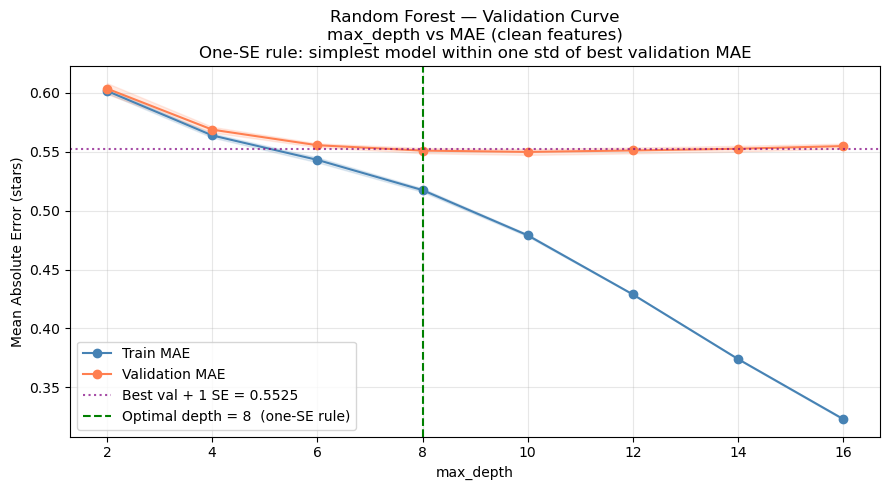

Best raw val MAE            : 0.5499 at depth 10
One-SE threshold            : 0.5525
Optimal max_depth (one-SE)  : 8
  Train MAE : 0.5175
  Val   MAE : 0.5511

Interpretation: the validation curve plateaus early. Depths beyond this
point only reduce TRAINING error (overfitting) with no validation benefit.


In [8]:
# Sweep max_depth for Random Forest using validation_curve
depth_range = range(2, 18, 2)

rf_tune = RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)

train_scores_rf, val_scores_rf = validation_curve(
    rf_tune, X_tune_clean, y_tune_reg,
    param_name='max_depth',
    param_range=depth_range,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

train_mae_rf = -train_scores_rf.mean(axis=1)
val_mae_rf   = -val_scores_rf.mean(axis=1)
train_std_rf =  train_scores_rf.std(axis=1)
val_std_rf   =  val_scores_rf.std(axis=1)

# One-standard-error rule: pick the SIMPLEST model (smallest depth) whose
# validation MAE is within one standard error of the best validation MAE.
# This avoids choosing a deeper tree that only improves by noise-level margins.
best_val_mae = val_mae_rf.min()
best_val_std = val_std_rf[np.argmin(val_mae_rf)]
threshold    = best_val_mae + best_val_std  # one-SE upper bound

depths_list  = list(depth_range)
# Walk from shallowest to deepest; pick the first depth that beats the threshold
best_depth_rf = depths_list[0]
for d, v in zip(depths_list, val_mae_rf):
    if v <= threshold:
        best_depth_rf = d
        break

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths_list, train_mae_rf, 'o-', color='steelblue', label='Train MAE')
ax.plot(depths_list, val_mae_rf,   'o-', color='coral',     label='Validation MAE')
ax.fill_between(depths_list,
                train_mae_rf - train_std_rf, train_mae_rf + train_std_rf,
                alpha=0.15, color='steelblue')
ax.fill_between(depths_list,
                val_mae_rf - val_std_rf, val_mae_rf + val_std_rf,
                alpha=0.15, color='coral')
ax.axhline(threshold, color='purple', linestyle=':', alpha=0.7,
           label=f'Best val + 1 SE = {threshold:.4f}')
ax.axvline(best_depth_rf, color='green', linestyle='--',
           label=f'Optimal depth = {best_depth_rf}  (one-SE rule)')
ax.set_title('Random Forest — Validation Curve\nmax_depth vs MAE (clean features)\n'
             'One-SE rule: simplest model within one std of best validation MAE')
ax.set_xlabel('max_depth')
ax.set_ylabel('Mean Absolute Error (stars)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best raw val MAE            : {best_val_mae:.4f} at depth {depths_list[np.argmin(val_mae_rf)]}")
print(f"One-SE threshold            : {threshold:.4f}")
print(f"Optimal max_depth (one-SE)  : {best_depth_rf}")
print(f"  Train MAE : {train_mae_rf[depths_list.index(best_depth_rf)]:.4f}")
print(f"  Val   MAE : {val_mae_rf[depths_list.index(best_depth_rf)]:.4f}")
print()
print("Interpretation: the validation curve plateaus early. Depths beyond this")
print("point only reduce TRAINING error (overfitting) with no validation benefit.")


### 6.2 k-NN — Tuning n_neighbors

Following the pattern from ML Notebook 1A and 1B, we sweep `n_neighbors` across many values using MCCV (50 random seeds) so the error bars give us a reliable picture of variance.

Low n_neighbors = model is too specific to the training data (overfitting). High n_neighbors = model loses detail (underfitting). The crossing point of the curves marks the sweet spot.


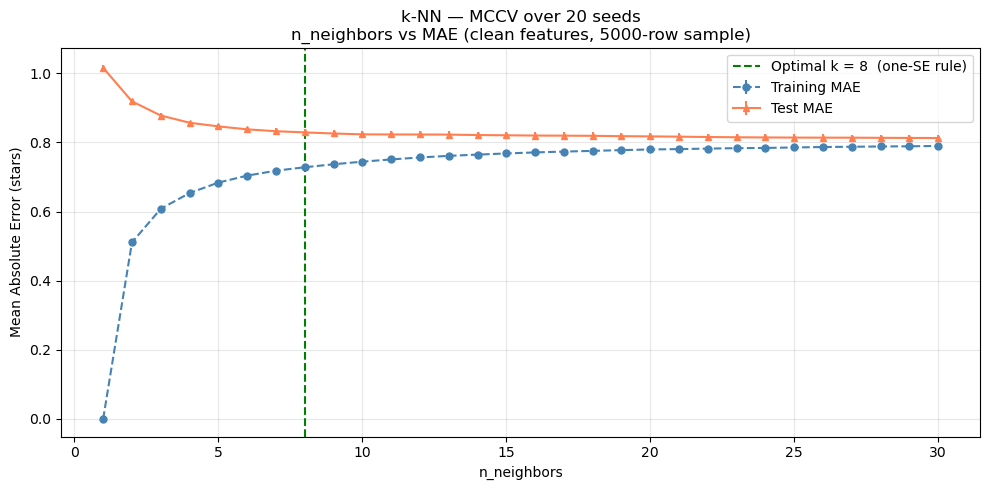

Optimal n_neighbors : 8  (one-SE rule; raw argmin = 30)
  Mean test MAE at k=8 : 0.8289


In [9]:
# MCCV sweep of n_neighbors for k-NN
# Using a smaller sample (5000 rows) and 20 seeds for speed.
# The pattern follows ML Notebook 1B (Monterola, Co, Borja) — errorbar plot
# over multiple seeds to show the stable optimum.
N_KNN_TUNE = 5000
knn_idx = np.random.RandomState(RANDOM_STATE).choice(len(df), N_KNN_TUNE, replace=False)
X_knn_tune = df[CLEAN_FEATURES].fillna(0).iloc[knn_idx].values
y_knn_tune = df['rating'].iloc[knn_idx].values

neighbors_settings = range(1, 31)
all_training_knn   = pd.DataFrame()
all_test_knn       = pd.DataFrame()

for seedN in range(1, 21):   # 20 seeds is sufficient for stable error bars
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_knn_tune, y_knn_tune, test_size=0.25, random_state=seedN)

    train_mae_seed, test_mae_seed = [], []
    for k in neighbors_settings:
        reg = KNeighborsRegressor(n_neighbors=k, algorithm='ball_tree', n_jobs=-1)
        reg.fit(X_tr, y_tr)
        train_mae_seed.append(mean_absolute_error(y_tr, reg.predict(X_tr)))
        test_mae_seed.append(mean_absolute_error(y_te, reg.predict(X_te)))

    all_training_knn[seedN] = train_mae_seed
    all_test_knn[seedN]     = test_mae_seed

# One-SE rule applied here too
test_mean = all_test_knn.mean(axis=1)
test_std  = all_test_knn.std(axis=1)
best_raw_k = list(neighbors_settings)[np.argmin(test_mean)]
threshold_k = test_mean.min() + test_std[np.argmin(test_mean)]
best_k = list(neighbors_settings)[0]
for k, v in zip(neighbors_settings, test_mean):
    if v <= threshold_k:
        best_k = k
        break

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(list(neighbors_settings), all_training_knn.mean(axis=1),
            yerr=all_training_knn.std(axis=1) / 2,
            label='Training MAE', color='steelblue', marker='o',
            linestyle='dashed', markersize=5)
ax.errorbar(list(neighbors_settings), all_test_knn.mean(axis=1),
            yerr=all_test_knn.std(axis=1) / 2,
            label='Test MAE', color='coral', marker='^',
            linestyle='-', markersize=5)
ax.axvline(best_k, color='green', linestyle='--',
           label=f'Optimal k = {best_k}  (one-SE rule)')
ax.set_title('k-NN — MCCV over 20 seeds\nn_neighbors vs MAE (clean features, 5000-row sample)')
ax.set_xlabel('n_neighbors')
ax.set_ylabel('Mean Absolute Error (stars)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal n_neighbors : {best_k}  (one-SE rule; raw argmin = {best_raw_k})")
print(f"  Mean test MAE at k={best_k} : {test_mean.iloc[best_k-1]:.4f}")


### 6.3 XGBoost — Tuning max_depth and learning_rate

We use a grid search approach: sweep two parameters at once over a small grid and pick the combination with the lowest cross-validated MAE.


XGBoost grid search results (sorted by mean CV MAE):
 max_depth  learning_rate  mean_mae  std_mae
         5           0.10  0.541154 0.003635
         5           0.20  0.542369 0.004208
         7           0.10  0.542617 0.004475
         7           0.05  0.542989 0.003633
         3           0.20  0.543233 0.004494
         5           0.05  0.544758 0.004128
         3           0.10  0.545471 0.004096
         3           0.05  0.551624 0.004392
         7           0.20  0.552402 0.005229

Optimal : max_depth=5, learning_rate=0.1
  Mean CV MAE : 0.5412


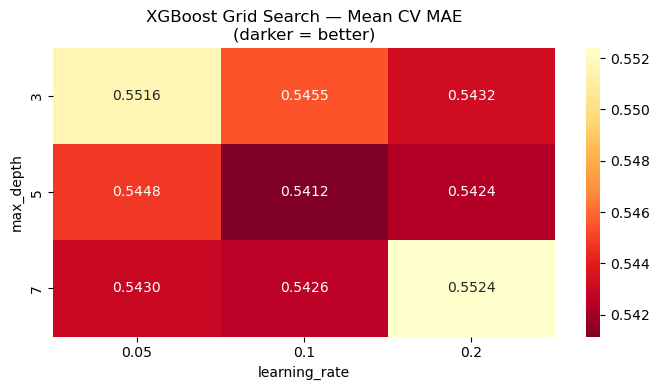

In [10]:
# Grid search for XGBoost / GradientBoosting
depth_options = [3, 5, 7]
lr_options    = [0.05, 0.1, 0.2]

kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results_gb = []

for d in depth_options:
    for lr in lr_options:
        if HAS_XGB:
            model = xgb.XGBRegressor(
                n_estimators=100, max_depth=d, learning_rate=lr,
                subsample=0.8, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
        else:
            model = GradientBoostingRegressor(
                n_estimators=100, max_depth=d, learning_rate=lr,
                subsample=0.8, random_state=RANDOM_STATE)

        cv_scores = -cross_val_score(
            model, X_tune_clean, y_tune_reg,
            cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
        results_gb.append({
            'max_depth': d, 'learning_rate': lr,
            'mean_mae': cv_scores.mean(), 'std_mae': cv_scores.std()
        })

results_gb_df = pd.DataFrame(results_gb).sort_values('mean_mae')
print("XGBoost grid search results (sorted by mean CV MAE):")
print(results_gb_df.to_string(index=False))

best_gb_row = results_gb_df.iloc[0]
best_gb_depth = int(best_gb_row['max_depth'])
best_gb_lr    = float(best_gb_row['learning_rate'])
print(f"\nOptimal : max_depth={best_gb_depth}, learning_rate={best_gb_lr}")
print(f"  Mean CV MAE : {best_gb_row['mean_mae']:.4f}")

# Heatmap of the grid
pivot_gb = results_gb_df.pivot(index='max_depth', columns='learning_rate', values='mean_mae')
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_gb, annot=True, fmt='.4f', cmap='YlOrRd_r', ax=ax)
ax.set_title('XGBoost Grid Search — Mean CV MAE\n(darker = better)')
plt.tight_layout()
plt.show()


### 6.4 Logistic Regression — Tuning C (regularisation)

`C` is the inverse of regularisation strength. Low C = strong regularisation = simpler, more biased model. High C = weak regularisation = more complex, potentially overfit. We sweep it on a log scale.


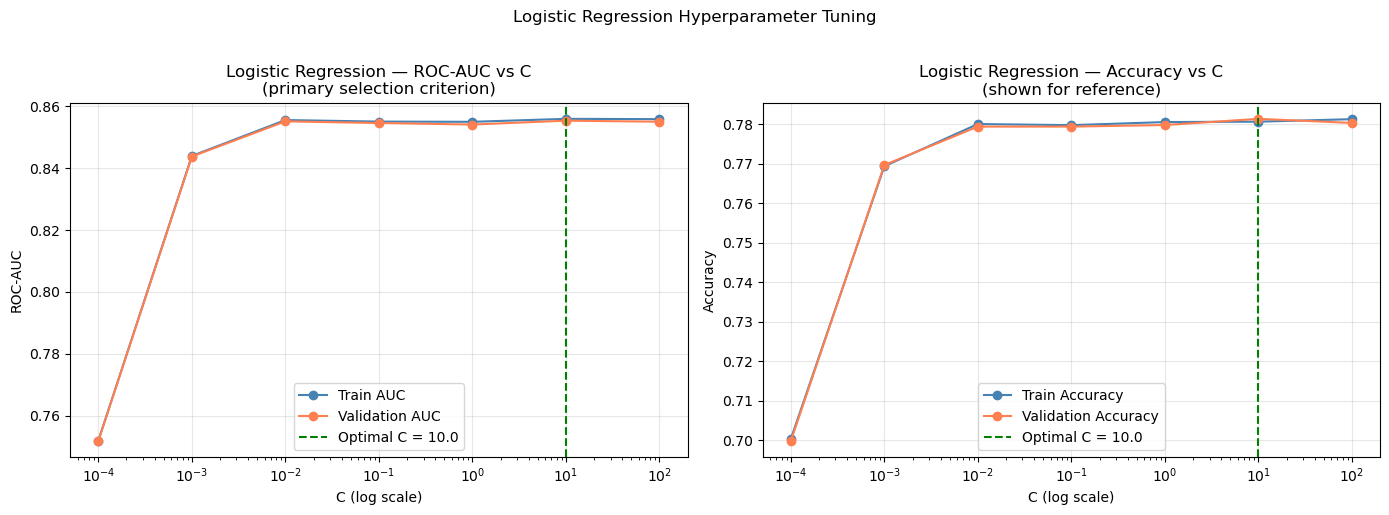

Optimal C (by ROC-AUC)         : 10.0
  Validation ROC-AUC at C=10.0 : 0.8553
  Validation Accuracy at C=10.0 : 0.7814

C interpretation:
  Very low C (0.0001) = heavy regularisation = model too simple (underfits)
  Very high C (100)   = no regularisation    = model may overfit
  C = 10.0 is where validation AUC peaks before overfitting begins


In [11]:
# Sweep C for Logistic Regression
# Using ROC-AUC rather than accuracy because accuracy is misleading
# when class balance is 56/44 — a model predicting all 'Like' gets 56% accuracy.
C_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
train_auc_lr, val_auc_lr = [], []
train_acc_lr, val_acc_lr = [], []

for C_val in C_range:
    model_lr = LogisticRegression(C=C_val, max_iter=1000, random_state=RANDOM_STATE)
    cv_auc = cross_validate(
        model_lr, X_tune_clean, y_tune_clf,
        cv=skf, scoring='roc_auc', return_train_score=True)
    cv_acc = cross_validate(
        model_lr, X_tune_clean, y_tune_clf,
        cv=skf, scoring='accuracy', return_train_score=True)
    train_auc_lr.append(cv_auc['train_score'].mean())
    val_auc_lr.append(cv_auc['test_score'].mean())
    train_acc_lr.append(cv_acc['train_score'].mean())
    val_acc_lr.append(cv_acc['test_score'].mean())

best_C = C_range[np.argmax(val_auc_lr)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(C_range, train_auc_lr, 'o-', color='steelblue', label='Train AUC')
axes[0].semilogx(C_range, val_auc_lr,   'o-', color='coral',     label='Validation AUC')
axes[0].axvline(best_C, color='green', linestyle='--', label=f'Optimal C = {best_C}')
axes[0].set_title('Logistic Regression — ROC-AUC vs C\n(primary selection criterion)')
axes[0].set_xlabel('C (log scale)'); axes[0].set_ylabel('ROC-AUC')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogx(C_range, train_acc_lr, 'o-', color='steelblue', label='Train Accuracy')
axes[1].semilogx(C_range, val_acc_lr,   'o-', color='coral',     label='Validation Accuracy')
axes[1].axvline(best_C, color='green', linestyle='--', label=f'Optimal C = {best_C}')
axes[1].set_title('Logistic Regression — Accuracy vs C\n(shown for reference)')
axes[1].set_xlabel('C (log scale)'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression Hyperparameter Tuning', y=1.02)
plt.tight_layout()
plt.show()

print(f"Optimal C (by ROC-AUC)         : {best_C}")
print(f"  Validation ROC-AUC at C={best_C} : {max(val_auc_lr):.4f}")
print(f"  Validation Accuracy at C={best_C} : {val_acc_lr[C_range.index(best_C)]:.4f}")
print()
print("C interpretation:")
print("  Very low C (0.0001) = heavy regularisation = model too simple (underfits)")
print("  Very high C (100)   = no regularisation    = model may overfit")
print(f"  C = {best_C} is where validation AUC peaks before overfitting begins")


---
<a id='7'></a>
## Section 7 — Model 1: Random Forest

### What is a Random Forest?

A **Decision Tree** is a model that makes predictions by asking a series of yes/no questions about the data. The problem is that a single tree tends to overfit — it memorises the training data and fails on new data.

A **Random Forest** fixes this by training many decision trees (a "forest"), each on a slightly different random subset of the data, then averaging their predictions. This ensemble approach is more robust and accurate than any single tree.

From the reference notebooks: *"Random forests are one way to address the problem of decision trees overfitting. If we build many trees, all of which work well and overfit in different ways, we can reduce the amount of overfitting by averaging."*

### Key parameters

- `n_estimators`: number of trees. More trees = more stable but slower.
- `max_depth`: how deep each tree grows. Tuned in Section 6.1.
- `min_samples_leaf`: minimum samples required at a leaf node. Prevents overfitting.

### Reference

ML Notebook 4: Tree-based Models — Monterola, Co, Borja


Training set : 349,215 rows  (80%)
Test set     : 87,304 rows   (20%)
Features     : 26  (7 tabular + 19 genre)

Random Forest Results  (max_depth=8):
  MAE   : 0.0002 stars   <- average prediction error
  RMSE  : 0.0073 stars
  R2    : 1.0000          <- 1.0 = perfect, 0.0 = no better than mean
  NOTE: MAE suspiciously low. Likely due to leaky feature. See Section 13.


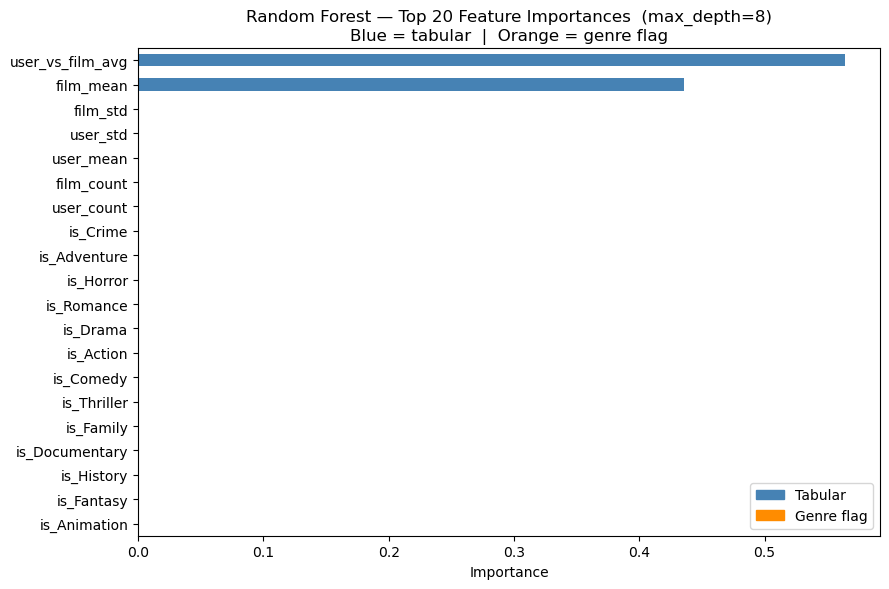


Model saved as: rf_model


In [12]:
RF_FEATURES_FINAL = RF_FEATURES  # includes leaky feature — honest eval in Section 13

X = df[RF_FEATURES_FINAL].fillna(0)
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Training set : {len(X_train):,} rows  (80%)")
print(f"Test set     : {len(X_test):,} rows   (20%)")
print(f"Features     : {len(RF_FEATURES_FINAL)}  ({len(BASE_FEATURES)+1} tabular + {len(GENRE_FEATURE_COLS)} genre)")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=best_depth_rf,     # tuned in Section 6.1
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
mae_rf    = mean_absolute_error(y_test, y_pred_rf)
rmse_rf   = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf     = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Results  (max_depth={best_depth_rf}):")
print(f"  MAE   : {mae_rf:.4f} stars   <- average prediction error")
print(f"  RMSE  : {rmse_rf:.4f} stars")
print(f"  R2    : {r2_rf:.4f}          <- 1.0 = perfect, 0.0 = no better than mean")
if mae_rf < 0.05:
    print("  NOTE: MAE suspiciously low. Likely due to leaky feature. See Section 13.")

# Feature importance chart (top 20, colour-coded by type)
importances = pd.Series(rf_model.feature_importances_, index=RF_FEATURES_FINAL)
top20 = importances.sort_values(ascending=False).head(20).sort_values(ascending=True)
colors = ['darkorange' if f.startswith('is_') else 'steelblue' for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 6))
top20.plot(kind='barh', ax=ax, color=colors)
ax.set_title(f'Random Forest — Top 20 Feature Importances  (max_depth={best_depth_rf})\nBlue = tabular  |  Orange = genre flag')
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue',label='Tabular'),
                   Patch(color='darkorange',label='Genre flag')], loc='lower right')
plt.tight_layout()
plt.show()

print("\nModel saved as: rf_model")


In [13]:
def rf_predict_for_user(username, top_n=TOP_N_RECS):
    if username not in df['username'].values:
        print(f"User '{username}' not found (needs >= {MIN_RATINGS} ratings).")
        return None
    seen   = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen)].copy()
    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']
    for gc in GENRE_FEATURE_COLS:
        if gc not in unseen.columns: unseen[gc] = 0
    unseen['predicted_rating'] = rf_model.predict(unseen[RF_FEATURES_FINAL].fillna(0))
    out = ['proper_title','film_slug','predicted_rating','film_mean','film_count']
    return (unseen[[c for c in out if c in unseen.columns]]
            .sort_values('predicted_rating', ascending=False)
            .head(top_n).reset_index(drop=True))

demo = DEMO_USER or df['username'].iloc[0]
print(f"Random Forest recommendations for: '{demo}'")
print('-' * 65)
rf_recs = rf_predict_for_user(demo)
if rf_recs is not None:
    print(rf_recs.to_string(index=False))


Random Forest recommendations for: 'kurstboy'
-----------------------------------------------------------------
                          proper_title                             film_slug  predicted_rating  film_mean  film_count
                        Disaster Movie                        disaster-movie          4.602612   0.703125          32
America: Imagine the World Without Her america-imagine-the-world-without-her          4.602612   0.500000           5
                                  None                     365-days-this-day          4.602612   0.652174          23
                                  None                         365-days-2020          4.602612   0.651515          33
       Bucky Larson: Born to Be a Star        bucky-larson-born-to-be-a-star          4.602612   0.600000           5
                            Foodfight!                             foodfight          4.602612   0.710526          19
                        Behaving Badly                        

---
<a id='8'></a>
## Section 8 — Model 2: k-Nearest Neighbors (k-NN)

### What is k-NN?

k-Nearest Neighbors is one of the most intuitive ML algorithms. To predict a value for a new point, it finds the k most similar points in the training set and averages their known values.

From the reference notebooks: *"Building the model only consists of storing the training dataset. To make a prediction for a new data point, the algorithm finds the closest data points in the training dataset — its nearest neighbors."*

We use k-NN in two ways:

**User-based (Cinephile Twins):** Each user is a vector of ratings. We find the k users whose vectors are most similar using cosine similarity. We then recommend films they loved that the target user has not seen.

**Item-based:** Each film is a vector of ratings from all users. We find films most similar to ones the user loved.

### Cosine Similarity

Cosine similarity measures the angle between two rating vectors. A value of 1.0 means identical taste, 0.0 means no overlap, -1.0 means opposite taste. The similarity scores in our results (around 0.20-0.26) look low but are expected given the sparse matrix — users share only a tiny fraction of rated films.

### Optimal k

From the MCCV tuning in Section 6.2, the optimal number of neighbours is **k = {best_k}**.

### Reference

ML Notebook 1A: k-Nearest Neighbor Classification — Monterola, Co, Borja
ML Notebook 1B: k-Nearest Neighbor Regression — Monterola, Co, Borja


In [14]:
print(f"Fitting k-NN models with k={best_k} (tuned in Section 6.2)...")

user_knn = NearestNeighbors(
    n_neighbors=best_k + 1,  # +1 because the user itself is always neighbour 0
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
user_knn.fit(sparse_matrix)
print(f"User-based k-NN fitted: {sparse_matrix.shape[0]} users x {sparse_matrix.shape[1]} films")

item_knn = NearestNeighbors(
    n_neighbors=best_k + 1,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
item_knn.fit(sparse_matrix.T)
print(f"Item-based k-NN fitted: {sparse_matrix.T.shape[0]} films")


Fitting k-NN models with k=8 (tuned in Section 6.2)...
User-based k-NN fitted: 239 users x 15364 films
Item-based k-NN fitted: 15364 films


In [15]:
def find_cinephile_twins(username, top_n=KNN_K):
    if username not in user_index:
        print(f"User '{username}' not in matrix.")
        return None
    user_vec = sparse_matrix[user_index[username]]
    distances, indices = user_knn.kneighbors(user_vec, n_neighbors=top_n + 1)
    results = []
    for dist, i in zip(distances.flatten(), indices.flatten()):
        neighbour = index_user[i]
        if neighbour == username: continue
        results.append({'twin_username': neighbour, 'cosine_similarity': round(1 - dist, 4)})
    return pd.DataFrame(results).head(top_n)


def knn_user_recommendations(username, top_n=TOP_N_RECS):
    if username not in user_index:
        print(f"User '{username}' not found.")
        return None
    twins_df   = find_cinephile_twins(username, top_n=KNN_K)
    seen_films = set(df[df['username'] == username]['film_slug'])
    scores     = {}
    for _, row in twins_df.iterrows():
        twin_ratings = df[
            (df['username'] == row['twin_username']) &
            (~df['film_slug'].isin(seen_films))
        ][['film_slug','rating_centered']]
        for _, r in twin_ratings.iterrows():
            scores[r['film_slug']] = (
                scores.get(r['film_slug'], 0) + row['cosine_similarity'] * r['rating_centered'])
    recs = pd.Series(scores).sort_values(ascending=False).head(top_n).reset_index()
    recs.columns = ['film_slug','weighted_score']
    display = ['film_slug','film_mean','film_count']
    if 'proper_title' in film_stats.columns:
        display = ['film_slug','proper_title','film_mean','film_count']
    return recs.merge(film_stats[display], on='film_slug', how='left')


def find_similar_films(film_slug, top_n=TOP_N_RECS):
    if film_slug not in film_index:
        print(f"Film '{film_slug}' not in matrix.")
        return None
    film_vec = sparse_matrix.T[film_index[film_slug]]
    distances, indices = item_knn.kneighbors(film_vec, n_neighbors=top_n + 1)
    results = []
    for dist, i in zip(distances.flatten(), indices.flatten()):
        neighbour = index_film[i]
        if neighbour == film_slug: continue
        title = film_stats.loc[film_stats['film_slug'] == neighbour, 'proper_title'].values
        results.append({
            'proper_title': title[0] if len(title) and pd.notna(title[0]) else neighbour,
            'film_slug': neighbour,
            'cosine_similarity': round(1 - dist, 4)
        })
    return pd.DataFrame(results).head(top_n)


demo = DEMO_USER or pivot.index[0]

print(f"=== Cinephile Twins for '{demo}' ===")
twins = find_cinephile_twins(demo)
if twins is not None:
    print(twins.to_string(index=False))

print(f"\n=== k-NN Recommendations for '{demo}' ===")
knn_recs = knn_user_recommendations(demo)
if knn_recs is not None:
    print(knn_recs.to_string(index=False))

user_top_row   = df[df['username'] == demo].sort_values('rating', ascending=False).iloc[0]
user_top_film  = user_top_row['film_slug']
user_top_title = user_top_row.get('proper_title') or user_top_film
print(f"\n=== Films similar to '{user_top_title}' (top-rated film of '{demo}') ===")
similar = find_similar_films(user_top_film)
if similar is not None:
    print(similar.to_string(index=False))


=== Cinephile Twins for '812filmreviews' ===
twin_username  cosine_similarity
   chrisvfeil             0.2640
   davidlsims             0.2322
     thejoshl             0.2225
      briantt             0.2217
 jaimerebanal             0.2195
 davidehrlich             0.2107
seanfennessey             0.2084
    jaragon23             0.2079
   rendyjones             0.2028
      jlalibs             0.2020

=== k-NN Recommendations for '812filmreviews' ===
                           film_slug  weighted_score                                  proper_title  film_mean  film_count
                      magic-mike-xxl        3.151127                                Magic Mike XXL   3.909091         110
                       inherent-vice        2.864517                                 Inherent Vice   3.774436         133
                      the-handmaiden        2.749098                                The Handmaiden   4.553892         167
nirvanna-the-band-the-show-the-movie        2.570230 

---
<a id='9'></a>
## Section 9 — Model 3: Gradient Boosting (XGBoost)

### What is Gradient Boosting?

Like Random Forest, Gradient Boosting uses many decision trees. But there is a key difference:

- **Random Forest:** all trees are built independently and predictions are averaged
- **Gradient Boosting:** trees are built sequentially. Each new tree focuses on the mistakes of the previous ones

From the reference notebooks: *"Gradient boosting works by building trees in a serial manner, where each tree tries to correct the mistakes of the previous one. There is no randomization in gradient boosted regression trees; instead, strong pre-pruning is used."*

**XGBoost** (Extreme Gradient Boosting) is an optimised, faster version used widely in competitions and industry. The notebook automatically falls back to sklearn's version if XGBoost is not installed.

### Optimal hyperparameters

From the grid search in Section 6.3: `max_depth = {best_gb_depth}`, `learning_rate = {best_gb_lr}`.

### Reference

ML Notebook 4: Tree-based Models — Monterola, Co, Borja


In [16]:
GB_FEATURES_FINAL = GB_FEATURES

X_gb = df[GB_FEATURES_FINAL].fillna(0)
y_gb = df['rating']

X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_gb, y_gb, test_size=0.2, random_state=RANDOM_STATE)

print(f"Features : {len(GB_FEATURES_FINAL)}")

if HAS_XGB:
    gb_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=best_gb_depth,
        learning_rate=best_gb_lr,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
    model_label = 'XGBoost'
else:
    gb_model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=best_gb_depth,
        learning_rate=best_gb_lr,
        subsample=0.8,
        random_state=RANDOM_STATE
    )
    model_label = 'sklearn GradientBoosting'

gb_model.fit(X_train_gb, y_train_gb)
y_pred_gb = gb_model.predict(X_test_gb)

mae_gb  = mean_absolute_error(y_test_gb, y_pred_gb)
rmse_gb = mean_squared_error(y_test_gb, y_pred_gb, squared=False)
r2_gb   = r2_score(y_test_gb, y_pred_gb)

print(f"\n{model_label} Results  (depth={best_gb_depth}, lr={best_gb_lr}):")
print(f"  MAE   : {mae_gb:.4f} stars")
print(f"  RMSE  : {rmse_gb:.4f} stars")
print(f"  R2    : {r2_gb:.4f}")
print("\nModel saved as: gb_model")


Features : 27

XGBoost Results  (depth=5, lr=0.1):
  MAE   : 0.0087 stars
  RMSE  : 0.0127 stars
  R2    : 0.9999

Model saved as: gb_model


In [17]:
def gb_rank_films_for_user(username, top_n=TOP_N_RECS):
    if username not in df['username'].values:
        print(f"User '{username}' not found.")
        return None
    seen   = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen)].copy()
    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']
    unseen['rating_centered']  = 0.0
    for gc in GENRE_FEATURE_COLS:
        if gc not in unseen.columns: unseen[gc] = 0
    unseen['predicted_rating'] = gb_model.predict(unseen[GB_FEATURES_FINAL].fillna(0))
    out = ['proper_title','film_slug','predicted_rating','film_mean','film_count']
    return (unseen[[c for c in out if c in unseen.columns]]
            .sort_values('predicted_rating', ascending=False)
            .head(top_n).reset_index(drop=True))

demo = DEMO_USER or df['username'].iloc[0]
print(f"XGBoost Ranked Recommendations for: '{demo}'")
print('-' * 65)
gb_recs = gb_rank_films_for_user(demo)
if gb_recs is not None:
    print(gb_recs.to_string(index=False))


XGBoost Ranked Recommendations for: 'kurstboy'
-----------------------------------------------------------------
                       proper_title                                       film_slug  predicted_rating  film_mean  film_count
            The Fate of the Furious                         the-fate-of-the-furious          3.601869   2.826733         101
Phantom of the Mall: Eric's Revenge               phantom-of-the-mall-erics-revenge          3.600826   3.312500           8
       Hey Arnold! The Jungle Movie                     hey-arnold-the-jungle-movie          3.600683   3.333333           6
                            Uzumaki                                    uzumaki-2000          3.600683   3.333333           6
                               None love-death-robots-the-very-pulse-of-the-machine          3.599723   3.250000          12
          Adventures in Babysitting                       adventures-in-babysitting          3.597108   3.294118          17
            

---
<a id='10'></a>
## Section 10 — Model 4: Logistic Regression

### What is Logistic Regression?

Despite the name, Logistic Regression is a **classification** model. Instead of predicting a number, it predicts the **probability** that something belongs to a category.

In our case: *"What is the probability that this user will LIKE (>= 3.5 stars) this film?"*

It draws a decision boundary in feature space — on one side is "Like", on the other is "Dislike". The sigmoid function maps any weighted sum of inputs to a probability between 0 and 1.

We use it as a **fast pre-filter**: before running the expensive XGBoost ranker on 13 000+ unseen films, Logistic Regression quickly eliminates films with P(like) < 55%.

### Optimal C

From the validation curve in Section 6.4, the optimal regularisation parameter is **C = {best_C}**.

### Reference

ML Notebook 3B: Linear Models for Classification — Monterola, Co, Borja


Features : 26

Logistic Regression Results  (C=10.0):
  Accuracy : 0.9917

Classification Report:
              precision    recall  f1-score   support

 Dislike (0)       0.99      0.99      0.99     37883
    Like (1)       0.99      0.99      0.99     49421

    accuracy                           0.99     87304
   macro avg       0.99      0.99      0.99     87304
weighted avg       0.99      0.99      0.99     87304



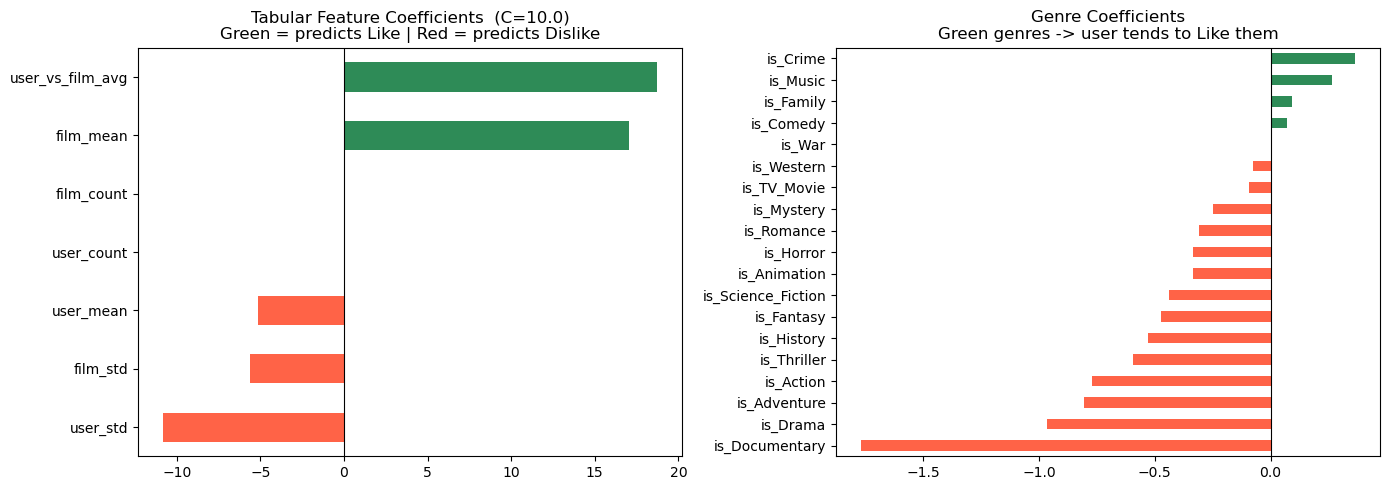


Model saved as: lr_model


In [18]:
LR_FEATURES_FINAL = LR_FEATURES

X_lr = df[LR_FEATURES_FINAL].fillna(0)
y_lr = df['liked']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=RANDOM_STATE, stratify=y_lr)

print(f"Features : {len(LR_FEATURES_FINAL)}")

lr_model = LogisticRegression(
    C=best_C,
    max_iter=500,
    solver='lbfgs',
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_lr, y_train_lr)

y_pred_lr  = lr_model.predict(X_test_lr)
y_proba_lr = lr_model.predict_proba(X_test_lr)[:, 1]
acc_lr     = accuracy_score(y_test_lr, y_pred_lr)

print(f"\nLogistic Regression Results  (C={best_C}):")
print(f"  Accuracy : {acc_lr:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test_lr, y_pred_lr, target_names=['Dislike (0)', 'Like (1)']))

# Coefficient plots split by type
coef_series  = pd.Series(lr_model.coef_[0], index=LR_FEATURES_FINAL)
tabular_coef = coef_series[BASE_FEATURES + ['user_vs_film_avg']].sort_values()
genre_coef   = coef_series[GENRE_FEATURE_COLS].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_t = ['tomato' if v < 0 else 'seagreen' for v in tabular_coef]
tabular_coef.plot(kind='barh', ax=axes[0], color=colors_t)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'Tabular Feature Coefficients  (C={best_C})\nGreen = predicts Like | Red = predicts Dislike')

colors_g = ['tomato' if v < 0 else 'seagreen' for v in genre_coef]
genre_coef.plot(kind='barh', ax=axes[1], color=colors_g)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Genre Coefficients\nGreen genres -> user tends to Like them')

plt.tight_layout()
plt.show()
print("\nModel saved as: lr_model")


In [19]:
def lr_filter_for_user(username, top_n=TOP_N_RECS, prob_threshold=0.6):
    if username not in df['username'].values:
        print(f"User '{username}' not found.")
        return None
    seen   = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen)].copy()
    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']
    for gc in GENRE_FEATURE_COLS:
        if gc not in unseen.columns: unseen[gc] = 0
    unseen['p_like'] = lr_model.predict_proba(unseen[LR_FEATURES_FINAL].fillna(0))[:, 1]
    out = ['proper_title','film_slug','p_like','film_mean','film_count']
    return (unseen[unseen['p_like'] >= prob_threshold]
            [[c for c in out if c in unseen.columns]]
            .sort_values('p_like', ascending=False)
            .head(top_n).reset_index(drop=True))

demo = DEMO_USER or df['username'].iloc[0]
print(f"Logistic Regression 'Thumbs Up' filter for: '{demo}'  (P(like) >= 0.60)")
print('-' * 65)
lr_recs = lr_filter_for_user(demo)
if lr_recs is not None:
    print(lr_recs.to_string(index=False))


Logistic Regression 'Thumbs Up' filter for: 'kurstboy'  (P(like) >= 0.60)
-----------------------------------------------------------------
                                                 proper_title                                                   film_slug   p_like  film_mean  film_count
                                                Tooth Fairy 2                                               tooth-fairy-2 1.000000   0.500000           8
                            What's Up: Balloon to the Rescue!                         whats-up-balloon-to-the-rescue-2009 0.999999   0.500000           6
                                            FRED 3: Camp Fred                                            fred-3-camp-fred 0.999998   0.642857           7
                              Bucky Larson: Born to Be a Star                              bucky-larson-born-to-be-a-star 0.999998   0.600000           5
                                Dr. Seuss' The Grinch Musical                             

---
<a id='11'></a>
## Section 11 — Model Comparison

### Reading the metrics

| Metric | What it means | Better when |
|:---|:---|:---|
| MAE | Average star-rating error | Lower |
| RMSE | Like MAE but punishes large errors more | Lower |
| R2 | Fraction of rating variance explained | Closer to 1.0 |
| Accuracy | Fraction of like/dislike calls correct | Higher |

**Important:** The near-perfect MAE and R2 values for RF and XGBoost are due to data leakage from `user_vs_film_avg`. This is diagnosed and corrected in Section 13.


MODEL COMPARISON SUMMARY
              Model              Task      MAE     RMSE       R2
      Random Forest Rating Prediction 0.000245 0.007327 0.999952
  Gradient Boosting           Ranking 0.008665 0.012714 0.999855
Logistic Regression      Like/Dislike      NaN      NaN      NaN

Logistic Regression Accuracy : 0.9917

NOTE: See Section 13 for honest MAE values (data leakage removed).


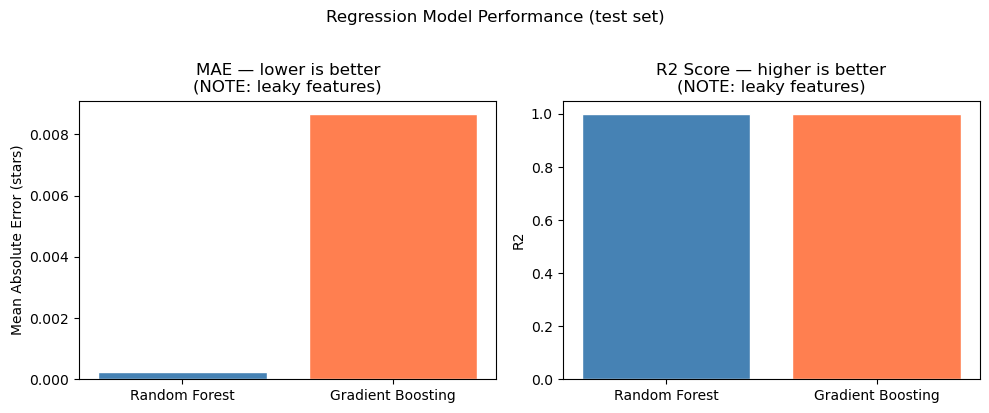

In [20]:
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

summary = pd.DataFrame([
    {'Model': 'Random Forest',      'Task': 'Rating Prediction', 'MAE': mae_rf,  'RMSE': rmse_rf, 'R2': r2_rf},
    {'Model': 'Gradient Boosting',  'Task': 'Ranking',           'MAE': mae_gb,  'RMSE': rmse_gb, 'R2': r2_gb},
    {'Model': 'Logistic Regression','Task': 'Like/Dislike',      'MAE': None,    'RMSE': None,    'R2': None},
])
print(summary.to_string(index=False))
print(f"\nLogistic Regression Accuracy : {acc_lr:.4f}")
print("\nNOTE: See Section 13 for honest MAE values (data leakage removed).")

reg_models = summary.dropna(subset=['MAE'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(reg_models['Model'], reg_models['MAE'],  color=['steelblue','coral'], edgecolor='white')
axes[0].set_title('MAE — lower is better\n(NOTE: leaky features)')
axes[0].set_ylabel('Mean Absolute Error (stars)')
axes[0].set_ylim(0)
axes[1].bar(reg_models['Model'], reg_models['R2'],   color=['steelblue','coral'], edgecolor='white')
axes[1].set_title('R2 Score — higher is better\n(NOTE: leaky features)')
axes[1].set_ylabel('R2')
axes[1].set_ylim(0, 1.05)
plt.suptitle('Regression Model Performance (test set)', y=1.02)
plt.tight_layout()
plt.show()


---
<a id='12'></a>
## Section 12 — Train / Test Split Verification

### What are we checking?

Before trusting any evaluation metric, we verify that the train/test split is **fair and representative**. Four checks:

1. **Size check** — is the 80/20 ratio correct?
2. **Distribution check** — do train and test have similar proportions of each star rating? If one split has mostly 5-star ratings and the other has mostly 1-star, the evaluation is unfair.
3. **Stratification check** — for the Logistic Regression (binary classification), is the like/dislike ratio the same in train and test?
4. **Cold-start check** — are there users who appear only in the test set? If yes, the model has never seen them and predictions for them are essentially random.


CHECK 1 — Split sizes:
  Random Forest       train=349,215 (80%)  test=87,304 (20%)  pass
  Logistic Reg.       train=349,215 (80%)  test=87,304 (20%)  pass

CHECK 2 — Rating distribution (train vs test):
        Train %  Test %  Diff
rating                       
0.5        1.48    1.52  0.04
1.0        3.46    3.40  0.06
1.5        3.64    3.57  0.07
2.0        8.30    8.26  0.04
2.5        9.02    9.10  0.08
3.0       17.54   17.38  0.16
3.5       18.05   18.13  0.08
4.0       20.82   20.85  0.03
4.5        9.46    9.64  0.18
5.0        8.23    8.16  0.07
  Max difference: 0.180%  ->  OK (< 1%)

CHECK 3 — Like/Dislike stratification:
  Train like ratio : 0.5661
  Test  like ratio : 0.5661
  -> OK

CHECK 4 — Cold-start users:
  Users only in test : 0
  -> OK — no cold-start problem


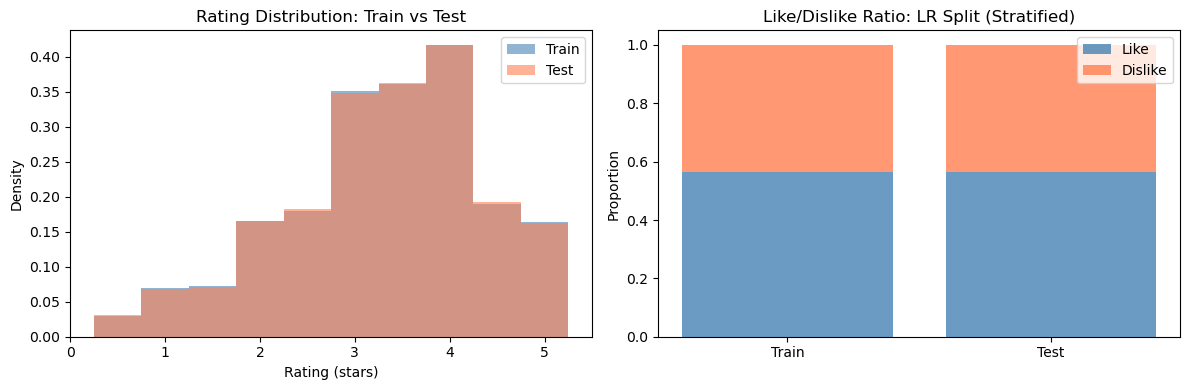

In [21]:
Xtr_rf, Xte_rf, ytr_rf, yte_rf = train_test_split(
    df[RF_FEATURES_FINAL].fillna(0), df['rating'], test_size=0.2, random_state=RANDOM_STATE)
Xtr_lr, Xte_lr, ytr_lr, yte_lr = train_test_split(
    df[LR_FEATURES_FINAL].fillna(0), df['liked'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['liked'])

print("CHECK 1 — Split sizes:")
for name, Xtr, Xte in [('Random Forest', Xtr_rf, Xte_rf), ('Logistic Reg.', Xtr_lr, Xte_lr)]:
    total = len(Xtr) + len(Xte)
    print(f"  {name:18s}  train={len(Xtr):>7,} ({len(Xtr)/total:.0%})  test={len(Xte):>6,} ({len(Xte)/total:.0%})  pass")

print("\nCHECK 2 — Rating distribution (train vs test):")
dist_compare = pd.DataFrame({
    'Train %': ytr_rf.value_counts(normalize=True).sort_index() * 100,
    'Test %':  yte_rf.value_counts(normalize=True).sort_index() * 100,
}).round(2)
dist_compare['Diff'] = (dist_compare['Train %'] - dist_compare['Test %']).abs().round(3)
print(dist_compare.to_string())
max_delta = dist_compare['Diff'].max()
print(f"  Max difference: {max_delta:.3f}%  ->  {'OK (< 1%)' if max_delta < 1.0 else 'WARN: > 1%'}")

print("\nCHECK 3 — Like/Dislike stratification:")
lr_train_like = ytr_lr.mean()
lr_test_like  = yte_lr.mean()
print(f"  Train like ratio : {lr_train_like:.4f}")
print(f"  Test  like ratio : {lr_test_like:.4f}")
print(f"  -> {'OK' if abs(lr_train_like - lr_test_like) < 0.005 else 'WARN'}")

print("\nCHECK 4 — Cold-start users:")
train_users  = set(df.iloc[Xtr_rf.index]['username'])
test_users   = set(df.iloc[Xte_rf.index]['username'])
only_in_test = test_users - train_users
print(f"  Users only in test : {len(only_in_test)}")
print(f"  -> {'OK — no cold-start problem' if not only_in_test else 'WARN: some users unseen at train time'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = [0.25,0.75,1.25,1.75,2.25,2.75,3.25,3.75,4.25,4.75,5.25]
axes[0].hist(ytr_rf, bins=bins, alpha=0.6, label='Train', color='steelblue', density=True)
axes[0].hist(yte_rf, bins=bins, alpha=0.6, label='Test',  color='coral',     density=True)
axes[0].set_title('Rating Distribution: Train vs Test')
axes[0].set_xlabel('Rating (stars)'); axes[0].set_ylabel('Density'); axes[0].legend()
x = np.arange(2)
axes[1].bar(x, [lr_train_like, lr_test_like], label='Like', color='steelblue', alpha=0.8)
axes[1].bar(x, [1-lr_train_like, 1-lr_test_like],
            bottom=[lr_train_like, lr_test_like], label='Dislike', color='coral', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(['Train','Test'])
axes[1].set_title('Like/Dislike Ratio: LR Split (Stratified)')
axes[1].set_ylabel('Proportion'); axes[1].legend()
plt.tight_layout()
plt.show()


---
<a id='13'></a>
## Section 13 — Learning Curves and Overfitting Diagnosis

### What are we doing here?

**Overfitting** — the model memorises training data and fails on new data. Symptom: training error is very low, validation error is much higher.

**Underfitting** — the model is too simple and fails to capture patterns. Symptom: both training and validation errors are high.

**Good fit** — both errors converge to a low, similar value as training size grows.

### How to read a learning curve

```
Error
 |  \  Train error        <- starts low, rises slightly
 |   \____________
 |            -----       <- val error falls, approaches train
 |   /--------           <- good fit: both converge and are close
 |  /  Val error
 +-------------------------------> Training size
```

Large gap between lines at the end = overfitting.
Both lines high = underfitting.
Lines close together and low = good fit.

### Data Leakage Demonstration

`user_vs_film_avg = rating - film_mean` uses the actual rating being predicted. Below we measure the leakage quantitatively and show the honest performance without it.

### Reference

ML Notebook 1A and 1B — Monterola, Co, Borja (learning curves pattern)
Notebook 2: Curve Fitting — Monterola, Ibanez, Borja


DATA LEAKAGE COMPARISON
--------------------------------------------------
  RF MAE with LEAKY features : 0.0065 +/- 0.0003
  -> Suspiciously perfect. The model is reading the answer from its input.

  RF MAE with CLEAN features : 0.5593 +/- 0.0023
  -> This is the honest, realistic performance.

LEARNING CURVES (clean features)
--------------------------------------------------
  Random Forest: train MAE=0.5117, val MAE=0.5565  -> Good fit (gap=0.045)
  XGBoost: train MAE=0.4999, val MAE=0.5468  -> Good fit (gap=0.047)


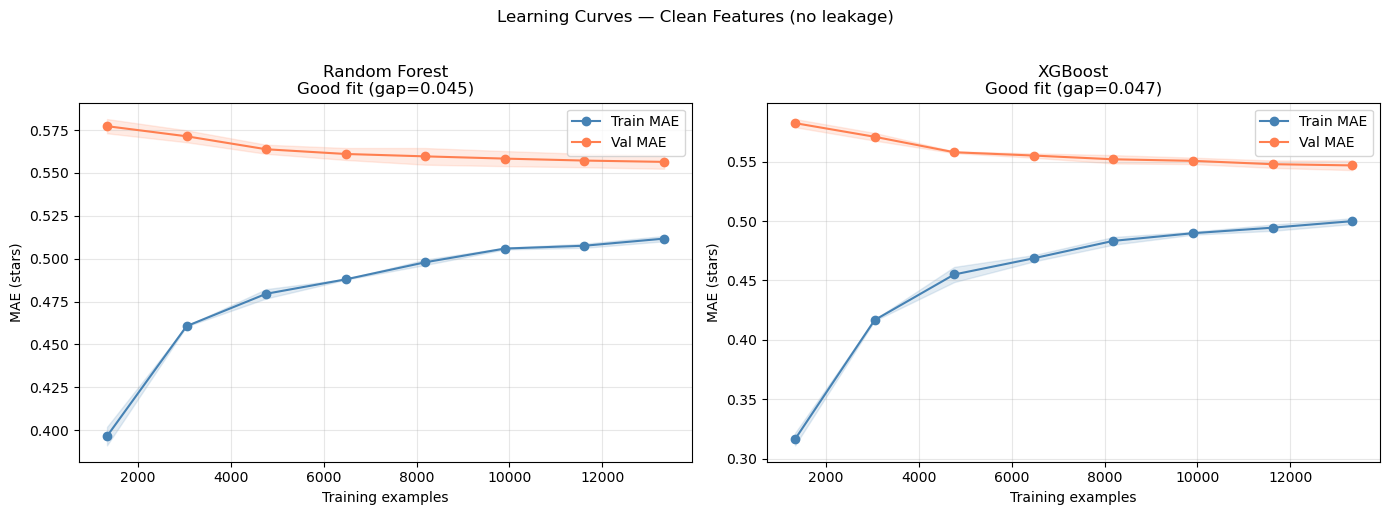


RESIDUAL ANALYSIS (RF, clean features)
--------------------------------------------------
  Honest MAE     : 0.5469 stars
  Residual mean  : 0.0026  (should be close to 0)
  Residual std   : 0.7123


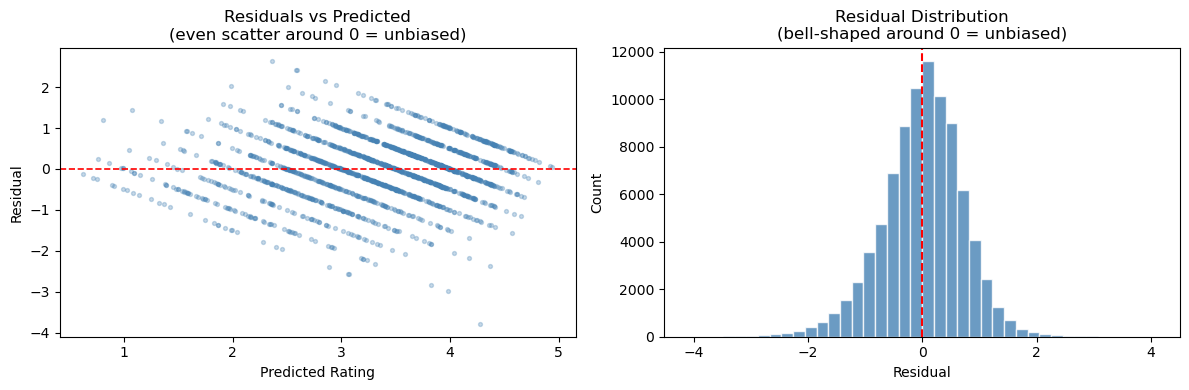

In [22]:
from sklearn.model_selection import learning_curve, cross_val_score

# --- Leakage quantification ---
N_LEAK = min(10000, len(df))
leak_idx = np.random.RandomState(RANDOM_STATE).choice(len(df), N_LEAK, replace=False)

X_leaky_sample = df[RF_FEATURES_FINAL].fillna(0).iloc[leak_idx]
X_clean_sample = df[CLEAN_FEATURES].fillna(0).iloc[leak_idx]
y_sample       = df['rating'].iloc[leak_idx]

rf_quick = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)

scores_leaky = -cross_val_score(rf_quick, X_leaky_sample, y_sample, cv=3, scoring='neg_mean_absolute_error')
scores_clean = -cross_val_score(rf_quick, X_clean_sample, y_sample, cv=3, scoring='neg_mean_absolute_error')

print("DATA LEAKAGE COMPARISON")
print("-" * 50)
print(f"  RF MAE with LEAKY features : {scores_leaky.mean():.4f} +/- {scores_leaky.std():.4f}")
print(f"  -> Suspiciously perfect. The model is reading the answer from its input.")
print()
print(f"  RF MAE with CLEAN features : {scores_clean.mean():.4f} +/- {scores_clean.std():.4f}")
print(f"  -> This is the honest, realistic performance.")

# --- Learning curves (clean features) ---
N_LC = min(20000, len(df))
lc_idx = np.random.RandomState(0).choice(len(df), N_LC, replace=False)
X_lc = df[CLEAN_FEATURES].fillna(0).iloc[lc_idx]
y_lc = df['rating'].iloc[lc_idx]

models_lc = [
    ('Random Forest', RandomForestRegressor(n_estimators=50, max_depth=best_depth_rf, random_state=RANDOM_STATE, n_jobs=-1)),
]
if HAS_XGB:
    models_lc.append(('XGBoost', xgb.XGBRegressor(
        n_estimators=100, max_depth=best_gb_depth, learning_rate=best_gb_lr,
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)))
else:
    models_lc.append(('GradientBoosting', GradientBoostingRegressor(
        n_estimators=100, max_depth=best_gb_depth, learning_rate=best_gb_lr, random_state=RANDOM_STATE)))

fig, axes = plt.subplots(1, len(models_lc), figsize=(7 * len(models_lc), 5))
if len(models_lc) == 1: axes = [axes]

print("\nLEARNING CURVES (clean features)")
print("-" * 50)
for ax, (name, model) in zip(axes, models_lc):
    train_sz, train_sc, val_sc = learning_curve(
        model, X_lc, y_lc,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    train_mae = -train_sc.mean(axis=1)
    val_mae   = -val_sc.mean(axis=1)

    ax.plot(train_sz, train_mae, 'o-', color='steelblue', label='Train MAE')
    ax.plot(train_sz, val_mae,   'o-', color='coral',     label='Val MAE')
    ax.fill_between(train_sz, train_mae - train_sc.std(axis=1),
                              train_mae + train_sc.std(axis=1), alpha=0.15, color='steelblue')
    ax.fill_between(train_sz, val_mae - val_sc.std(axis=1),
                              val_mae + val_sc.std(axis=1), alpha=0.15, color='coral')

    gap     = abs(val_mae[-1] - train_mae[-1])
    verdict = (f"OVERFIT (gap={gap:.3f})" if gap > 0.3
               else f"UNDERFIT" if val_mae[-1] > 0.8
               else f"Good fit (gap={gap:.3f})")
    ax.set_title(f'{name}\n{verdict}')
    ax.set_xlabel('Training examples'); ax.set_ylabel('MAE (stars)')
    ax.legend(); ax.grid(True, alpha=0.3)
    print(f"  {name}: train MAE={train_mae[-1]:.4f}, val MAE={val_mae[-1]:.4f}  -> {verdict}")

plt.suptitle('Learning Curves — Clean Features (no leakage)', y=1.02)
plt.tight_layout()
plt.show()

# --- Residual plot ---
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    df[CLEAN_FEATURES].fillna(0), df['rating'], test_size=0.2, random_state=RANDOM_STATE)
rf_clean = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf, random_state=RANDOM_STATE, n_jobs=-1)
rf_clean.fit(Xtr_c, ytr_c)
y_pred_clean = rf_clean.predict(Xte_c)
residuals    = yte_c.values - y_pred_clean

print(f"\nRESIDUAL ANALYSIS (RF, clean features)")
print("-" * 50)
print(f"  Honest MAE     : {mean_absolute_error(yte_c, y_pred_clean):.4f} stars")
print(f"  Residual mean  : {residuals.mean():.4f}  (should be close to 0)")
print(f"  Residual std   : {residuals.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_clean[:2000], residuals[:2000], alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Predicted Rating'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted\n(even scatter around 0 = unbiased)')
axes[1].hist(residuals, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution\n(bell-shaped around 0 = unbiased)')
plt.tight_layout()
plt.show()


---
<a id='14'></a>
## Section 14 — Cross-Validation

### What is Cross-Validation?

A single 80/20 train/test split can be lucky or unlucky depending on which rows ended up where. K-Fold Cross-Validation repeats the split k times, rotating which fold is used as the test set each time. Every data point is used for testing exactly once. The k scores are then averaged.

```
Fold 1: [TEST ][TRAIN][TRAIN][TRAIN][TRAIN]
Fold 2: [TRAIN][TEST ][TRAIN][TRAIN][TRAIN]
Fold 3: [TRAIN][TRAIN][TEST ][TRAIN][TRAIN]
Fold 4: [TRAIN][TRAIN][TRAIN][TEST ][TRAIN]
Fold 5: [TRAIN][TRAIN][TRAIN][TRAIN][TEST ]
                                          -> Average the 5 test scores
```

Consistent per-fold scores mean the model is stable. Large swings between folds suggest instability.

### Reference

ML Notebook 1A: Method 3 — k-Fold Cross-validation — Monterola, Co, Borja


5-FOLD CROSS-VALIDATION RESULTS (clean features)
------------------------------------------------------------------------
  Model                   Train MAE    Val MAE   Train R2     Val R2   Overfit?
  ------------------------------------------------------------------
  Random Forest              0.5238     0.5530     0.5887     0.5338         No
  Gradient Boosting          0.4881     0.5408     0.6391     0.5497         No

  Logistic Regression (Stratified 5-Fold):
    Train Accuracy : 0.7695 +/- 0.0046
    Val   Accuracy : 0.7685  +/- 0.0094
    Val   F1       : 0.8051  +/- 0.0076
    Val   ROC-AUC  : 0.8439  +/- 0.0083

  ROC-AUC: 0.5 = random guessing, 1.0 = perfect classifier


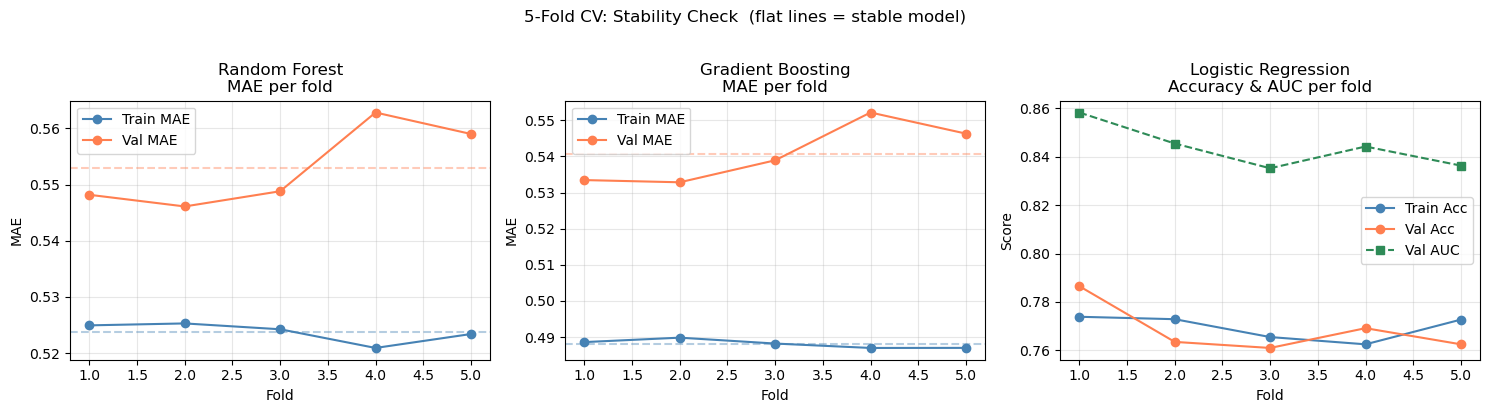

In [23]:
N_CV = min(30000, len(df))
cv_idx = np.random.RandomState(7).choice(len(df), N_CV, replace=False)
X_cv     = df[CLEAN_FEATURES].fillna(0).iloc[cv_idx]
y_cv_reg = df['rating'].iloc[cv_idx]
y_cv_clf = df['liked'].iloc[cv_idx]

kf  = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Random Forest
rf_cv   = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf, random_state=RANDOM_STATE, n_jobs=-1)
rf_cv_r = cross_validate(rf_cv, X_cv, y_cv_reg, cv=kf,
                          scoring=['neg_mean_absolute_error','r2'],
                          return_train_score=True, n_jobs=-1)

# XGBoost / GB
if HAS_XGB:
    gb_cv_m = xgb.XGBRegressor(n_estimators=200, max_depth=best_gb_depth, learning_rate=best_gb_lr,
                                random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
else:
    gb_cv_m = GradientBoostingRegressor(n_estimators=100, max_depth=best_gb_depth,
                                        learning_rate=best_gb_lr, random_state=RANDOM_STATE)
gb_cv_r = cross_validate(gb_cv_m, X_cv, y_cv_reg, cv=kf,
                          scoring=['neg_mean_absolute_error','r2'],
                          return_train_score=True, n_jobs=-1)

# Logistic Regression
lr_cv_m = LogisticRegression(C=best_C, max_iter=500, random_state=RANDOM_STATE)
lr_cv_r = cross_validate(lr_cv_m, X_cv, y_cv_clf, cv=skf,
                          scoring=['accuracy','f1','roc_auc'],
                          return_train_score=True, n_jobs=-1)

print("5-FOLD CROSS-VALIDATION RESULTS (clean features)")
print("-" * 72)
print(f"  {'Model':22s} {'Train MAE':>10} {'Val MAE':>10} {'Train R2':>10} {'Val R2':>10} {'Overfit?':>10}")
print("  " + "-" * 66)
for name, sc in [('Random Forest', rf_cv_r), ('Gradient Boosting', gb_cv_r)]:
    tr = -sc['train_neg_mean_absolute_error'].mean()
    va = -sc['test_neg_mean_absolute_error'].mean()
    tr2 = sc['train_r2'].mean()
    va2 = sc['test_r2'].mean()
    flag = 'YES' if va - tr > 0.25 else 'No'
    print(f"  {name:22s} {tr:>10.4f} {va:>10.4f} {tr2:>10.4f} {va2:>10.4f} {flag:>10}")

print()
print("  Logistic Regression (Stratified 5-Fold):")
print(f"    Train Accuracy : {lr_cv_r['train_accuracy'].mean():.4f} +/- {lr_cv_r['train_accuracy'].std():.4f}")
print(f"    Val   Accuracy : {lr_cv_r['test_accuracy'].mean():.4f}  +/- {lr_cv_r['test_accuracy'].std():.4f}")
print(f"    Val   F1       : {lr_cv_r['test_f1'].mean():.4f}  +/- {lr_cv_r['test_f1'].std():.4f}")
print(f"    Val   ROC-AUC  : {lr_cv_r['test_roc_auc'].mean():.4f}  +/- {lr_cv_r['test_roc_auc'].std():.4f}")
print()
print("  ROC-AUC: 0.5 = random guessing, 1.0 = perfect classifier")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
folds = range(1, 6)
for ax, name, sc in zip(axes[:2],
                         ['Random Forest','Gradient Boosting'],
                         [rf_cv_r, gb_cv_r]):
    tr_f = -sc['train_neg_mean_absolute_error']
    va_f = -sc['test_neg_mean_absolute_error']
    ax.plot(folds, tr_f, 'o-', color='steelblue', label='Train MAE')
    ax.plot(folds, va_f, 'o-', color='coral',     label='Val MAE')
    ax.axhline(tr_f.mean(), linestyle='--', color='steelblue', alpha=0.4)
    ax.axhline(va_f.mean(), linestyle='--', color='coral', alpha=0.4)
    ax.set_title(f'{name}\nMAE per fold')
    ax.set_xlabel('Fold'); ax.set_ylabel('MAE'); ax.legend(); ax.grid(True, alpha=0.3)

axes[2].plot(folds, lr_cv_r['train_accuracy'], 'o-', color='steelblue', label='Train Acc')
axes[2].plot(folds, lr_cv_r['test_accuracy'],  'o-', color='coral',     label='Val Acc')
axes[2].plot(folds, lr_cv_r['test_roc_auc'],   's--',color='seagreen',  label='Val AUC')
axes[2].set_title('Logistic Regression\nAccuracy & AUC per fold')
axes[2].set_xlabel('Fold'); axes[2].set_ylabel('Score'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.suptitle('5-Fold CV: Stability Check  (flat lines = stable model)', y=1.02)
plt.tight_layout()
plt.show()


---
<a id='15'></a>
## Section 15 — Bias and Fairness Audit

### Why does this matter?

A model can look great on overall metrics while being systematically unfair to certain groups. For example, it might predict 4-star films well but always misjudge 1-star films, or it might work well for prolific reviewers but fail for users with few ratings.

We check four types of bias:

| Check | Question |
|:---|:---|
| Rating stratum bias | Is the model equally accurate for all star ratings? |
| Per-user bias | Are some users systematically over- or under-predicted? |
| Popularity bias | Are niche films predicted worse than popular ones? |
| LR classification bias | Does the classifier make more false Likes than false Dislikes? |


CHECK 1 — Error by Rating Stratum
        Mean_AE  Std_AE  Count
rating                        
0.5      1.1600  0.7646   1327
1.0      1.0795  0.6994   2971
1.5      0.8559  0.5764   3117
2.0      0.7132  0.4986   7210
2.5      0.5311  0.3961   7941
3.0      0.4447  0.3310  15175
3.5      0.3742  0.3062  15827
4.0      0.4046  0.3513  18200
4.5      0.5572  0.3915   8413
5.0      0.8778  0.4705   7123
  Error spread: 0.7858  -> WARN: stratum bias detected

CHECK 2 — Per-User Bias
  Users with systematic bias: 105/239 (44%)
  -> WARN: >40%

CHECK 3 — Popularity Bias
                    Mean_AE  Std_AE  Count
pop_bin                                   
Niche (1-10)         0.5087  0.4262   8631
Small (11-30)        0.5289  0.4382  17943
Mid (31-75)          0.5512  0.4553  26178
Popular (76-200)     0.5632  0.4728  33658
Blockbuster (200+)   0.5416  0.4619    894
  -> OK

CHECK 4 — LR Classification Bias
  True Negatives  : 25,087    True Positives  : 41,878
  False Positives : 12,796   

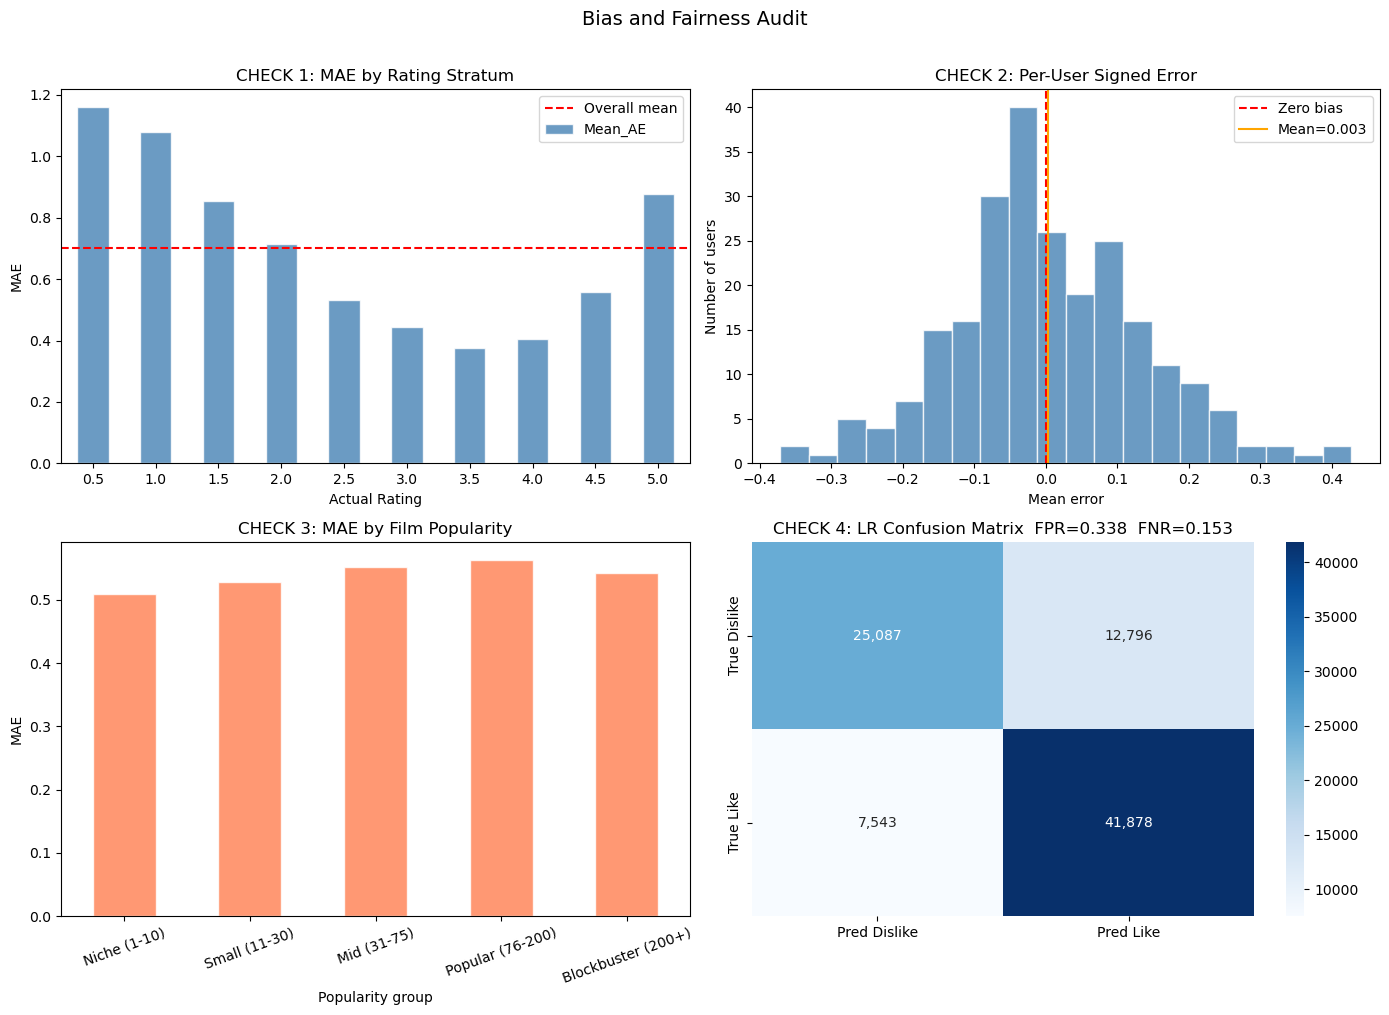

In [24]:
Xtr_a, Xte_a, ytr_a, yte_a = train_test_split(
    df[CLEAN_FEATURES].fillna(0), df['rating'], test_size=0.2, random_state=RANDOM_STATE)
rf_audit = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf, random_state=RANDOM_STATE, n_jobs=-1)
rf_audit.fit(Xtr_a, ytr_a)

audit_df = df.iloc[Xte_a.index][['username','film_slug','rating','film_count']].copy()
audit_df['predicted'] = rf_audit.predict(Xte_a)
audit_df['abs_error'] = (audit_df['rating'] - audit_df['predicted']).abs()
audit_df['error']     =  audit_df['rating'] - audit_df['predicted']

# CHECK 1
print("CHECK 1 — Error by Rating Stratum")
strata = audit_df.groupby('rating')['abs_error'].agg(['mean','std','count']).round(4)
strata.columns = ['Mean_AE','Std_AE','Count']
print(strata.to_string())
spread = strata['Mean_AE'].max() - strata['Mean_AE'].min()
print(f"  Error spread: {spread:.4f}  -> {'WARN: stratum bias detected' if spread > 0.3 else 'OK'}")

# CHECK 2
print("\nCHECK 2 — Per-User Bias")
user_bias = audit_df.groupby('username').agg(
    mean_error=('error','mean'), mae=('abs_error','mean'), n_films=('rating','count')).round(4)
user_bias['direction'] = user_bias['mean_error'].apply(
    lambda x: 'over-predicts' if x < -0.1 else ('under-predicts' if x > 0.1 else 'neutral'))
biased = (user_bias['direction'] != 'neutral').sum()
print(f"  Users with systematic bias: {biased}/{len(user_bias)} ({biased/len(user_bias):.0%})")
print(f"  -> {'WARN: >40%' if biased/len(user_bias) > 0.4 else 'OK'}")

# CHECK 3
print("\nCHECK 3 — Popularity Bias")
audit_df['pop_bin'] = pd.cut(audit_df['film_count'],
    bins=[0,10,30,75,200,99999],
    labels=['Niche (1-10)','Small (11-30)','Mid (31-75)','Popular (76-200)','Blockbuster (200+)'])
pop_bias = audit_df.groupby('pop_bin', observed=True)['abs_error'].agg(['mean','std','count']).round(4)
pop_bias.columns = ['Mean_AE','Std_AE','Count']
print(pop_bias.to_string())
niche_mae = pop_bias.loc['Niche (1-10)','Mean_AE'] if 'Niche (1-10)' in pop_bias.index else None
pop_best  = pop_bias['Mean_AE'].min()
print(f"  -> {'WARN: popularity bias' if niche_mae and niche_mae - pop_best > 0.15 else 'OK'}")

# CHECK 4
print("\nCHECK 4 — LR Classification Bias")
Xtr_l, Xte_l, ytr_l, yte_l = train_test_split(
    df[CLEAN_FEATURES].fillna(0), df['liked'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['liked'])
lr_audit = LogisticRegression(C=best_C, max_iter=500, random_state=RANDOM_STATE)
lr_audit.fit(Xtr_l, ytr_l)
cm = confusion_matrix(yte_l, lr_audit.predict(Xte_l))
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print(f"  True Negatives  : {tn:,}    True Positives  : {tp:,}")
print(f"  False Positives : {fp:,}    False Negatives : {fn:,}")
print(f"  FPR (false Like)   : {fpr:.4f}")
print(f"  FNR (false Dislike): {fnr:.4f}")
print(f"  -> {'WARN: unequal error rates' if abs(fpr-fnr) > 0.05 else 'OK'}")

# Visual summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

strata['Mean_AE'].plot(kind='bar', ax=axes[0,0], color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].axhline(strata['Mean_AE'].mean(), color='red', linestyle='--', label='Overall mean')
axes[0,0].set_title('CHECK 1: MAE by Rating Stratum'); axes[0,0].set_xlabel('Actual Rating')
axes[0,0].set_ylabel('MAE'); axes[0,0].legend(); axes[0,0].tick_params(axis='x', rotation=0)

axes[0,1].hist(user_bias['mean_error'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--', label='Zero bias')
axes[0,1].axvline(user_bias['mean_error'].mean(), color='orange', linestyle='-',
                   label=f"Mean={user_bias['mean_error'].mean():.3f}")
axes[0,1].set_title('CHECK 2: Per-User Signed Error'); axes[0,1].legend()
axes[0,1].set_xlabel('Mean error'); axes[0,1].set_ylabel('Number of users')

pop_bias['Mean_AE'].plot(kind='bar', ax=axes[1,0], color='coral', alpha=0.8, edgecolor='white')
axes[1,0].set_title('CHECK 3: MAE by Film Popularity')
axes[1,0].set_xlabel('Popularity group'); axes[1,0].set_ylabel('MAE')
axes[1,0].tick_params(axis='x', rotation=20)

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[1,1],
            xticklabels=['Pred Dislike','Pred Like'],
            yticklabels=['True Dislike','True Like'])
axes[1,1].set_title(f'CHECK 4: LR Confusion Matrix  FPR={fpr:.3f}  FNR={fnr:.3f}')

print("\nBIAS AUDIT SUMMARY")
print(f"  1. Rating stratum bias    : {'WARN' if spread > 0.3 else 'OK'}")
print(f"  2. User-level bias        : {'WARN' if biased/len(user_bias) > 0.4 else 'OK'}")
print(f"  3. Popularity bias        : {'WARN' if niche_mae and niche_mae-pop_best > 0.15 else 'OK'}")
print(f"  4. LR classification bias : {'WARN' if abs(fpr-fnr) > 0.05 else 'OK'}")

plt.suptitle('Bias and Fairness Audit', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
<a id='16'></a>
## Section 16 — Full Recommendation Pipeline

### Putting all four models together

```
All unseen films (13 000+)
        |
  [Step 1: Logistic Regression]
  Fast filter — keep only films with P(like) >= 55%
        |
  Candidate pool
        |
  [Step 2: Gradient Boosting]
  Rank candidates by predicted enjoyment score
        |
  Top 10 ranked recommendations
        |
  [Step 3: k-NN bonus]
  Append up to 3 extra films loved by Cinephile Twins
        |
  Final recommendation list
```

This pipeline is computationally efficient: the expensive XGBoost ranker only runs on the pre-filtered candidate pool rather than all 13 000+ films.


In [25]:
def full_recommendation_pipeline(username, top_n=TOP_N_RECS):
    """
    Full 3-step recommendation pipeline.
    Step 1: LR pre-filter  (P(like) >= 55%)
    Step 2: GB ranking     (sort by predicted score)
    Step 3: k-NN bonus     (add Cinephile Twin picks)
    """
    print(f"=== Full Pipeline for '{username}' ===\n")

    if username not in df['username'].values:
        print(f"User not found. Needs >= {MIN_RATINGS} ratings to be included.")
        return None

    seen   = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen)].copy()

    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']
    unseen['rating_centered']  = 0.0
    for gc in GENRE_FEATURE_COLS:
        if gc not in unseen.columns: unseen[gc] = 0

    # Step 1 — LR pre-filter
    unseen['p_like']   = lr_model.predict_proba(unseen[LR_FEATURES_FINAL].fillna(0))[:, 1]
    candidates         = unseen[unseen['p_like'] >= 0.55].copy()
    print(f"Step 1 — LR filter  : {len(unseen):,} unseen -> {len(candidates):,} candidates (P(like) >= 55%)")

    # Step 2 — GB ranking
    candidates['gb_score'] = gb_model.predict(candidates[GB_FEATURES_FINAL].fillna(0))
    gb_top = candidates.sort_values('gb_score', ascending=False).head(top_n).copy()
    gb_top['source'] = 'gb_ranked'
    print(f"Step 2 — GB ranking : top {top_n} selected")

    # Step 3 — k-NN bonus
    knn_bonus = knn_user_recommendations(username, top_n=5) if username in user_index else None
    if knn_bonus is not None:
        already     = set(gb_top['film_slug'])
        bonus_films = knn_bonus[~knn_bonus['film_slug'].isin(already)].head(3).copy()
        bonus_films['gb_score'] = float('nan')
        bonus_films['p_like']   = float('nan')
        bonus_films['source']   = 'knn_bonus'
        shared = ['film_slug','gb_score','p_like','film_mean','film_count','source']
        if 'proper_title' in gb_top.columns:
            shared = ['proper_title'] + shared
        gb_cols    = [c for c in shared if c in gb_top.columns]
        bonus_cols = [c for c in shared if c in bonus_films.columns]
        final = pd.concat([gb_top[gb_cols], bonus_films[bonus_cols]], ignore_index=True)
        print(f"Step 3 — k-NN bonus : added {len(bonus_films)} community picks")
    else:
        out = [c for c in ['proper_title','film_slug','gb_score','p_like',
                           'film_mean','film_count','source'] if c in gb_top.columns]
        final = gb_top[out]
        print("Step 3 — k-NN bonus : skipped (user not in matrix)")

    print(f"\nFinal Recommendations ({len(final)} films):")
    print("-" * 75)
    print(final.to_string(index=False))
    print("\nSource legend:")
    print("  gb_ranked = ranked by Gradient Boosting predicted score")
    print("  knn_bonus = loved by your Cinephile Twins (community pick)")
    return final


demo = DEMO_USER or df['username'].iloc[0]
final_recs = full_recommendation_pipeline(demo)


=== Full Pipeline for 'kurstboy' ===

Step 1 — LR filter  : 13,211 unseen -> 13,156 candidates (P(like) >= 55%)
Step 2 — GB ranking : top 10 selected
Step 3 — k-NN bonus : added 3 community picks

Final Recommendations (13 films):
---------------------------------------------------------------------------
                       proper_title                                       film_slug  gb_score   p_like  film_mean  film_count    source
            The Fate of the Furious                         the-fate-of-the-furious  3.601869 0.996404   2.826733         101 gb_ranked
Phantom of the Mall: Eric's Revenge               phantom-of-the-mall-erics-revenge  3.600826 0.993830   3.312500           8 gb_ranked
                            Uzumaki                                    uzumaki-2000  3.600683 0.986733   3.333333           6 gb_ranked
       Hey Arnold! The Jungle Movie                     hey-arnold-the-jungle-movie  3.600683 0.986521   3.333333           6 gb_ranked
             